# Анализ лояльности пользователей Яндекс Афиши

- Автор: Сокова Екатерина
- Дата: 14.04.2026

# Цели и задачи проекта

<font color='#777778'>Необходимо провести исследовательский анализ данных для команды маркетинга, чтобы лучше понимать поведение пользователей, и изучить информацию о том, какие пользователи с большей вероятностью возвращаются на платформу и делают заказы повторно.</font>

### Описание данных

<font color='#777778'>Для анализа была сделана выгрузка из базы данных SQL и получен датасет со следующими данными:
- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ;
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа ;
- `order_ts` — дата и время создания заказа;
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `event_name` — название мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия;
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

</font>

### Содержимое проекта

<font color='#777778'>
    
- [Загрузка данных и знакомство с ними](#accesingdata)
- [Предобработка данных](#typesofdata)
- [Исследовательский анализ данных](#dataanalysis)
- [Итоговый вывод и рекомендации](#conclusion)</font>

---

<a id="accesingdata"></a>
## Загрузка данных и знакомство с ними

Начнем с загрузки всех необходимых библиотек и модулей для подключения к базе данных SQL.

In [1]:
!pip install pyodbc

In [2]:
!pip install sqlalchemy

In [3]:
!pip install psycopg2-binary

In [4]:
import pandas as pd
from sqlalchemy import create_engine

In [5]:
db_config = {'user': 'praktikum_student', # имя пользователя
             'pwd': 'Sdf4$2;d-d30pp', # пароль
             'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
             'port': 6432, # порт подключения
             'db': 'data-analyst-afisha' # название базы данных
             }

In [6]:
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

In [7]:
engine = create_engine(connection_string)

Создадим и выгрузим в датасет запрос SQL для вывода всех необходимых данных для анализа.

In [8]:
query= '''
SELECT
user_id,
device_type_canonical,
order_id,
created_dt_msk AS order_dt,
created_ts_msk AS order_ts,
currency_code,
revenue,
tickets_count,
created_dt_msk::date - LAG(created_dt_msk::date) OVER (PARTITION BY user_id ORDER BY created_dt_msk) AS days_since_prev,
ap.event_id,
ae.event_name_code AS event_name,
service_name,
ae.event_type_main,
ar.region_name,
ac.city_name
FROM afisha.purchases as ap
JOIN afisha.events as ae USING (event_id)
JOIN afisha.city as ac USING (city_id)
JOIN afisha.regions as ar USING (region_id)
WHERE device_type_canonical IN ('mobile', 'desktop') AND event_type_main != 'фильм'
ORDER BY user_id
'''

In [9]:
# выгружаем в датафрейм запрос SQL и выводим первые строки
df = pd.read_sql_query(query, con=engine)
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,service_name,event_type_main,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,Край билетов,театр,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,Мой билет,выставки,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,За билетом!,другое,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,Лови билет!,другое,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,Билеты без проблем,стендап,Озернинский край,Родниковецк


In [10]:
# выводим информацию о датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  service_name           290611 non-null  object        
 12  event_type_main        290611 non-null  obje

Всего датасет содержит 290611 строк и 15 столбцов, в них представлена информация о пользователях Яндекс Афиши и мероприятиях, приобретенных этими пользователями.

После первичного анализа данных можно сделать следующие выводы:

- Названия столбцов указаны корректно, значения соответвуют своему описанию.
- Все представленные данные хранятся в типах данных float64, int64, datetime64 и object.

Значения в столбце `days_since_prev` определены как вещественные, однако, очевидно, что они являются целыми числами, поэтому для этого столбца следует изменить тип данных, предварительно обработав пропуски.
Все числовые значения (столбцы `order_id`, `revenue`, `tickets_count`, `days_since_prev`, `event_id`) можно оптимизировать.

Пропуски содержатся только в столбце `days_since_prev`, однако следует проверить и другие столбцы: в них могут встречаться значения-индикаторы, которые будут говорить об отсутствии данных.

---

### Промежуточный вывод

Первичное знакомство показывает, что названия столцов указаны корректно, а содержание данных соответствует своему описанию. Некоторые типа данных можно оптимизировать.
В датасете в столбце с количеством дней от предыдущей покупки пользователя содержатся пропуски, следует определить, как их обработать.

<a id="typesofdata"></a>
## Предобработка данных

**Задача 2.1:** 

Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведем выручку к единой валюте — российскому рублю.

---

In [11]:
# выгружаем датасет в курсами тенге
final_tickets_tenge_df = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')
final_tickets_tenge_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


Столбец `data` представлен в формате object, поэтому сначала преобразуем его в формат даты.

In [12]:
# преобразуем столбец data в формат даты и выведем информацию и первые 5 строк 
final_tickets_tenge_df['data'] = pd.to_datetime(final_tickets_tenge_df['data'], format='%Y-%m-%d')
final_tickets_tenge_df.info()
print(final_tickets_tenge_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   data     357 non-null    datetime64[ns]
 1   nominal  357 non-null    int64         
 2   curs     357 non-null    float64       
 3   cdx      357 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 11.3+ KB
        data  nominal     curs  cdx
0 2024-01-10      100  19.9391  kzt
1 2024-01-11      100  19.7255  kzt
2 2024-01-12      100  19.5839  kzt
3 2024-01-13      100  19.4501  kzt
4 2024-01-14      100  19.4501  kzt


In [13]:
# объединяем таблицы
df = df.merge(final_tickets_tenge_df, left_on = 'order_dt', right_on = 'data', how = 'left')
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,service_name,event_type_main,region_name,city_name,data,nominal,curs,cdx
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,Край билетов,театр,Каменевский регион,Глиногорск,2024-08-20,100,18.6972,kzt
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,Мой билет,выставки,Каменевский регион,Глиногорск,2024-07-23,100,18.3419,kzt
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,За билетом!,другое,Каменевский регион,Глиногорск,2024-10-06,100,19.6475,kzt
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,Лови билет!,другое,Североярская область,Озёрск,2024-07-13,100,18.5010,kzt
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,Билеты без проблем,стендап,Озернинский край,Родниковецк,2024-10-04,100,19.6648,kzt


In [14]:
# создаем функцию для конвертации
def convert_revenue(row):
    if row['currency_code'] == 'kzt':
        return row['revenue'] * row['curs'] / row['nominal']
    else:
        return row['revenue']

In [15]:
# применяем функцию и проверяем результат
df['revenue_rub'] = df.apply(convert_revenue, axis = 1)
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,service_name,event_type_main,region_name,city_name,data,nominal,curs,cdx,revenue_rub
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,Край билетов,театр,Каменевский регион,Глиногорск,2024-08-20,100,18.6972,kzt,1521.94
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,Мой билет,выставки,Каменевский регион,Глиногорск,2024-07-23,100,18.3419,kzt,289.45
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,За билетом!,другое,Каменевский регион,Глиногорск,2024-10-06,100,19.6475,kzt,1258.57
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,Лови билет!,другое,Североярская область,Озёрск,2024-07-13,100,18.5010,kzt,8.49
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,Билеты без проблем,стендап,Озернинский край,Родниковецк,2024-10-04,100,19.6648,kzt,1390.41


In [16]:
# проверяем результат конвертации для валюты kzt
df_kzt = df.loc[df['currency_code'] == 'kzt']
df_kzt

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,service_name,event_type_main,region_name,city_name,data,nominal,curs,cdx,revenue_rub
70,0033403583a55ed,mobile,7850214,2024-09-17,2024-09-17 16:52:06,kzt,518.10,4,20.0,559919,f5ec2467-ee48-42f3-89a0-a2d90d1d6fce,Билеты без проблем,другое,Верхоречная область,Серебрянка,2024-09-17,100,19.0125,kzt,98.503762
89,0040e12d70fae81,desktop,8634925,2024-09-02,2024-09-02 19:49:14,kzt,347.18,3,39.0,559476,61ec7c0e-ea0c-4a3e-a63a-09cbe1bc6177,Билеты без проблем,другое,Верхоречная область,Серебрянка,2024-09-02,100,18.9330,kzt,65.731589
96,0054b38b2653e6e,mobile,7625522,2024-09-09,2024-09-09 18:06:04,kzt,328.77,4,NaN,559582,524f434e-0381-4f47-9688-7c4e41961b65,Билеты без проблем,другое,Верхоречная область,Серебрянка,2024-09-09,100,18.5991,kzt,61.148261
277,00f4f5244501ce6,mobile,720419,2024-06-11,2024-06-11 20:15:57,kzt,22021.55,5,NaN,536826,76af4f88-c554-4e9e-9df4-1cc8aeec8959,Мой билет,концерты,Верхоречная область,Серебрянка,2024-06-11,100,19.8928,kzt,4380.702898
460,01370a0e9c1a7d5,desktop,5227657,2024-06-04,2024-06-04 13:28:17,kzt,7397.66,4,1.0,533803,0686ac7b-6f3e-4177-bb73-16b54acd1223,Мой билет,концерты,Шанырский регион,Широковка,2024-06-04,100,19.9833,kzt,1478.296591
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290484,ffc24188a1d58f2,mobile,6862648,2024-07-11,2024-07-11 12:39:48,kzt,4735.52,2,20.0,538828,603c97c6-b64f-4ec6-8de9-20b95c20b2b5,Билеты без проблем,концерты,Верхоречная область,Серебрянка,2024-07-11,100,18.2738,kzt,865.359454
290485,ffc24188a1d58f2,mobile,6763294,2024-09-05,2024-09-05 12:07:00,kzt,4735.52,2,56.0,538828,603c97c6-b64f-4ec6-8de9-20b95c20b2b5,Билеты без проблем,концерты,Верхоречная область,Серебрянка,2024-09-05,100,18.4217,kzt,872.363288
290486,ffc24188a1d58f2,mobile,3984021,2024-09-06,2024-09-06 19:20:03,kzt,1849.41,1,1.0,533803,0686ac7b-6f3e-4177-bb73-16b54acd1223,Мой билет,концерты,Шанырский регион,Широковка,2024-09-06,100,18.5504,kzt,343.072953
290488,ffc4133fbba20f4,mobile,8493898,2024-06-21,2024-06-21 13:41:39,kzt,3698.83,2,NaN,533803,0686ac7b-6f3e-4177-bb73-16b54acd1223,Мой билет,концерты,Шанырский регион,Широковка,2024-06-21,100,18.5791,kzt,687.209325


In [17]:
# удаляем лишние столбцы и проверяем результат
df = df.drop(columns=['data', 'nominal', 'curs','cdx'])
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,service_name,event_type_main,region_name,city_name,revenue_rub
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,Край билетов,театр,Каменевский регион,Глиногорск,1521.94
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,Мой билет,выставки,Каменевский регион,Глиногорск,289.45
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,За билетом!,другое,Каменевский регион,Глиногорск,1258.57
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,Лови билет!,другое,Североярская область,Озёрск,8.49
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,Билеты без проблем,стендап,Озернинский край,Родниковецк,1390.41


---

**Задача 2.2:**

- Проверим данные на пропущенные значения.
- Преобразуем типы данных в некоторых столбцах, сократим размерность при необходимости.
- Изучим значения в ключевых столбцах. 
---

In [18]:
# проверяем пропуски в столбцах
df.isna().sum()

user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
days_since_prev          21933
event_id                     0
event_name                   0
service_name                 0
event_type_main              0
region_name                  0
city_name                    0
revenue_rub                  0
dtype: int64

In [19]:
# подсчитываем долю строк с пропусками
df.isna().mean().sort_values(ascending=False)*100

days_since_prev          7.547202
user_id                  0.000000
device_type_canonical    0.000000
order_id                 0.000000
order_dt                 0.000000
order_ts                 0.000000
currency_code            0.000000
revenue                  0.000000
tickets_count            0.000000
event_id                 0.000000
event_name               0.000000
service_name             0.000000
event_type_main          0.000000
region_name              0.000000
city_name                0.000000
revenue_rub              0.000000
dtype: float64

Заменим пропуски в столбце `days_since_prev` на ноль.

In [20]:
# заменяем пропуски в столбце days_since_prev
df['days_since_prev'] = df['days_since_prev'].fillna(0)

In [21]:
# преобразуем тип данных в столбце days_since_prev в целочисленный
df['days_since_prev'] = df['days_since_prev'].astype(int)

In [22]:
# оптимизируем вещественный тип данных
df['revenue'] = pd.to_numeric(df['revenue'],downcast='float')
df['revenue_rub'] = pd.to_numeric(df['revenue_rub'],downcast='float')

In [23]:
# оптимизируем целочисленные типы данных
for column in ['order_id','tickets_count','days_since_prev','event_id']:
    df[column] = pd.to_numeric(df[column],downcast='integer')

In [24]:
# проверяем получившиеся в результате преобразования типы данных
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int32         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float32       
 7   tickets_count          290611 non-null  int8          
 8   days_since_prev        290611 non-null  int16         
 9   event_id               290611 non-null  int32         
 10  event_name             290611 non-null  object        
 11  service_name           290611 non-null  object        
 12  event_type_main        290611 non-null  obje

In [25]:
# проверяем, что даты в столбцах order_dt и order_ts совпадают
(df['order_dt']==df['order_ts'].dt.date).all()

True

Даты в столбцах совпадают.

Проверим значения в категориальных столбцах.

In [26]:
df['device_type_canonical'].unique()

array(['mobile', 'desktop'], dtype=object)

In [27]:
df['currency_code'].unique()

array(['rub', 'kzt'], dtype=object)

In [28]:
df['event_type_main'].unique()

array(['театр', 'выставки', 'другое', 'стендап', 'концерты', 'спорт',
       'ёлки'], dtype=object)

В категориальных столбцах значения, обозначающие пропуски в данных или отсутствие информации, отсутствуют.
Проверим строки, у которых в столбце `event_type_main` указано значение 'другое', а также количество таких строк.

In [29]:
df.loc[df['event_type_main']=='другое']

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,service_name,event_type_main,region_name,city_name,revenue_rub
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.569946,4,75,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,За билетом!,другое,Каменевский регион,Глиногорск,1258.569946
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.490000,2,0,387271,2f638715-8844-466c-b43f-378a627c419f,Лови билет!,другое,Североярская область,Озёрск,8.490000
26,001e7037d013f0f,mobile,1673330,2024-07-04,2024-07-04 08:06:44,rub,479.540009,2,0,83717,0f8e05fc-56be-4bc7-b775-e3cd61ae6fe4,Мой билет,другое,Златопольский округ,Кумсай,479.540009
38,002b75ca606ba46,desktop,3020989,2024-10-02,2024-10-02 13:54:33,rub,271.070007,4,63,573041,c1f637f3-f9e5-4026-a465-f500102213ea,Мой билет,другое,Каменевский регион,Глиногорск,271.070007
39,002b75ca606ba46,mobile,3020960,2024-10-02,2024-10-02 16:05:45,rub,203.300003,3,0,573041,c1f637f3-f9e5-4026-a465-f500102213ea,Мой билет,другое,Каменевский регион,Глиногорск,203.300003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290597,fffcd3dde79eb2c,mobile,8019371,2024-09-12,2024-09-12 14:47:03,rub,31.580000,3,0,384441,108c5bfa-b11e-47ac-a482-d0e76702508e,Лови билет!,другое,Североярская область,Озёрск,31.580000
290604,fffcd3dde79eb2c,mobile,4326395,2024-10-26,2024-10-26 17:43:23,rub,414.119995,4,4,571114,67173a55-dd4c-4f71-ba3a-adacd47464f4,Билеты без проблем,другое,Каменевский регион,Глиногорск,414.119995
290605,fffcd3dde79eb2c,mobile,368620,2024-10-27,2024-10-27 18:00:57,rub,965.570007,4,1,33189,e3dcdb45-9eaa-4ce4-9b85-1562e548172e,Весь в билетах,другое,Каменевский регион,Глиногорск,965.570007
290606,fffcd3dde79eb2c,mobile,368591,2024-10-27,2024-10-27 17:54:52,rub,965.570007,4,0,33189,e3dcdb45-9eaa-4ce4-9b85-1562e548172e,Весь в билетах,другое,Каменевский регион,Глиногорск,965.570007


Всего к этому типу события относятся 65867 строк и на первый взгляд какая-либо закономерность отсутствует.

Проверим данные в столбцах с названием сервиса покупки билетов, регионами и городами.

In [30]:
# проведем нормализацию данных столбца service_name и выведем список уникальных значений
df['service_name'] = df['service_name'].str.lower().str.strip()
sorted(df['service_name'].unique())

['crazy ticket!',
 'show_ticket',
 'билет по телефону',
 'билеты без проблем',
 'билеты в интернете',
 'билеты в руки',
 'быстробилет',
 'быстрый кассир',
 'весь в билетах',
 'восьмёрка',
 'вперёд!',
 'выступления.ру',
 'городской дом культуры',
 'дом культуры',
 'дырокол',
 'за билетом!',
 'зе бест!',
 'карандашру',
 'кино билет',
 'край билетов',
 'лимоны',
 'лови билет!',
 'лучшие билеты',
 'мир касс',
 'мой билет',
 'облачко',
 'прачечная',
 'радио ticket',
 'реестр',
 'росбилет',
 'тебе билет!',
 'телебилет',
 'тех билет',
 'цвет и билет',
 'шоу начинается!',
 'яблоко']

Значения, означаюшие пропуски, отсутствуют.

In [31]:
sorted(df['region_name'].unique())

['Белоярская область',
 'Берестовский округ',
 'Берёзовская область',
 'Боровлянский край',
 'Верховинская область',
 'Верхозёрский край',
 'Верхоречная область',
 'Ветренский регион',
 'Вишнёвский край',
 'Глиногорская область',
 'Голубевский округ',
 'Горицветская область',
 'Горноземский регион',
 'Горностепной регион',
 'Дальнеземская область',
 'Дальнезорский край',
 'Дубравная область',
 'Залесский край',
 'Заречная область',
 'Зеленоградский округ',
 'Златопольский округ',
 'Золотоключевской край',
 'Зоринский регион',
 'Каменевский регион',
 'Каменичская область',
 'Каменноозёрный край',
 'Каменноярский край',
 'Каменополянский округ',
 'Ключеводский округ',
 'Кристаловская область',
 'Кристальная область',
 'Крутоводская область',
 'Крутоводский регион',
 'Лесноярский край',
 'Лесодальний край',
 'Лесополянская область',
 'Лесостепной край',
 'Лесоярская область',
 'Луговая область',
 'Лугоградская область',
 'Малиновая область',
 'Малиновоярский округ',
 'Медовская область',


Значения, означаюшие пропуски, отсутствуют.

In [32]:
sorted(df['city_name'].unique())

['Айкольск',
 'Айсуак',
 'Акбастау',
 'Акбасты',
 'Акжолтау',
 'Алтынкала',
 'Алтынсай',
 'Байкуль',
 'Байсары',
 'Байтерековск',
 'Беловодск',
 'Белоярск',
 'Бережанка',
 'Бережанск',
 'Березиногорск',
 'Березиноск',
 'Березовцево',
 'Берестовец',
 'Берестяград',
 'Берёзиново',
 'Берёзовка',
 'Берёзогорск',
 'Берёзодальн',
 'Берёзополье',
 'Берёзореч',
 'Берёзоречье',
 'Бозарык',
 'Боровлянск',
 'Буркиттау',
 'Бурьяново',
 'Верховино',
 'Верховка',
 'Верхозолотск',
 'Верхозорье',
 'Верхоозёров',
 'Ветеринск',
 'Вишнёво',
 'Вишнёвогорск',
 'Вишнёводск',
 'Водниково',
 'Глиногорск',
 'Глиногорь',
 'Глиноград',
 'Глинозолото',
 'Глинозорь',
 'Глинолес',
 'Глинополин',
 'Глинополье',
 'Глинополянск',
 'Глинореч',
 'Глинянск',
 'Голубевск',
 'Голубино',
 'Гореловск',
 'Горицветск',
 'Горноград',
 'Горнодолинск',
 'Горнолесье',
 'Горнолуг',
 'Горнополец',
 'Горнополье',
 'Горнополянск',
 'Горнополяровск',
 'Горнополёк',
 'Горноставинск',
 'Горяново',
 'Дальнеград',
 'Дальнесветин',
 'Дальне

Значения, означаюшие пропуски, отсутствуют.

Проверим распределение численных данных и наличие в них выбросов. Для этого используем статистические показатели, гистограммы распределения значений или диаграммы размаха.

In [33]:
# проверим статистические показатели столбца revenue_rub
df['revenue_rub'].describe()

count    290611.000000
mean        555.571960
std         875.498169
min         -90.760002
25%         113.970001
50%         351.140015
75%         802.049988
max       81174.539062
Name: revenue_rub, dtype: float64

In [34]:
# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt

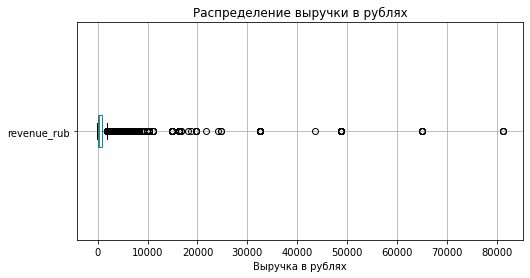

In [35]:
#Создадим диаграмму размаха значений в столбце revenue_rub
plt.figure(figsize=(8, 4))

df.boxplot(column='revenue_rub', vert=False)

plt.title('Распределение выручки в рублях')
plt.xlabel('Выручка в рублях')

plt.show()

Распределение выручки в рублях асимметричное, скошенное вправо. Минимальная выручка — отрицательная (-90,76 руб.), а максимальное — 81174,54 руб., что говорит о наличии выбросов. Среднее значение - 555,57 руб., тогда как медиана — 351,14 руб. Среднее значение существенно выше медианы, что также может быть следствием выбросов.

Проверим строки с отрицательным значением выручки и посчитаем их долю от общего числа строк.

In [36]:
# выводим значения с отрицатальной выручкой в рублях
df.loc[df['revenue_rub']<0]

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,service_name,event_type_main,region_name,city_name,revenue_rub
252,00eb3dc9baa1543,mobile,1594653,2024-06-29,2024-06-29 15:01:43,rub,-2.37,3,0,538650,ffe03bc6-0e0c-480d-b037-6a4b55540ab5,билеты без проблем,другое,Берёзовская область,Златопольск,-2.37
4539,02ea4583333f064,mobile,2360920,2024-09-03,2024-09-03 18:12:58,rub,-0.23,3,0,559772,592856bb-09a5-4d32-9534-0e02c6056e44,билеты без проблем,другое,Широковская область,Лесореченск,-0.23
4544,02ea4583333f064,mobile,2361094,2024-09-04,2024-09-04 09:34:53,rub,-0.15,2,0,559772,592856bb-09a5-4d32-9534-0e02c6056e44,билеты без проблем,другое,Широковская область,Лесореченск,-0.15
8135,043f669c9f734b1,mobile,166780,2024-09-27,2024-09-27 10:00:09,rub,-1.86,3,0,567183,9f571dad-b18a-4095-ac76-9db60d8dd97a,лучшие билеты,другое,Золотоключевской край,Луговинец,-1.86
8136,043f669c9f734b1,mobile,166809,2024-09-27,2024-09-27 10:56:35,rub,-0.62,1,0,567183,9f571dad-b18a-4095-ac76-9db60d8dd97a,лучшие билеты,другое,Золотоключевской край,Луговинец,-0.62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
288837,fe237d2cfd6e503,mobile,3700575,2024-10-12,2024-10-12 08:11:33,rub,-5.70,1,0,247058,a3214473-934e-44ad-a8da-82915f51583f,тебе билет!,концерты,Речицкая область,Радужанов,-5.70
288910,fe237d2cfd6e503,desktop,3523617,2024-10-15,2024-10-15 20:13:13,rub,-0.96,2,0,243963,80f5f95b-9a58-401d-b888-4261335ae290,лучшие билеты,другое,Ягодиновская область,Речинцево,-0.96
288911,fe237d2cfd6e503,desktop,3523646,2024-10-15,2024-10-15 20:32:18,rub,-1.43,3,0,243963,80f5f95b-9a58-401d-b888-4261335ae290,лучшие билеты,другое,Ягодиновская область,Речинцево,-1.43
289058,fe237d2cfd6e503,mobile,5445853,2024-10-21,2024-10-21 20:22:29,rub,-0.61,1,0,243393,1f30acba-8b62-41c3-aaea-a80bf58d0d26,лучшие билеты,другое,Ягодиновская область,Речинцево,-0.61


In [37]:
# посчитаем долю таких значений в процентах
len(df.loc[df['revenue_rub']<0]) / len(df) * 100

0.13110308969722412

Всего таких строк 381, что составляет 0,13% от общего размера датасета.
Такие аномалии могут быть связаны с возвратами, а также техническими ошибками при покупке билетов.
Так как доля таких значений маленькая, удалим такие строки.

In [38]:
df = df.loc[df['revenue_rub']>=0]
df

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,service_name,event_type_main,region_name,city_name,revenue_rub
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.939941,4,0,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,край билетов,театр,Каменевский регион,Глиногорск,1521.939941
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.450012,2,0,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,мой билет,выставки,Каменевский регион,Глиногорск,289.450012
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.569946,4,75,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,за билетом!,другое,Каменевский регион,Глиногорск,1258.569946
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.490000,2,0,387271,2f638715-8844-466c-b43f-378a627c419f,лови билет!,другое,Североярская область,Озёрск,8.490000
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.410034,3,83,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,билеты без проблем,стендап,Озернинский край,Родниковецк,1390.410034
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290606,fffcd3dde79eb2c,mobile,368591,2024-10-27,2024-10-27 17:54:52,rub,965.570007,4,0,33189,e3dcdb45-9eaa-4ce4-9b85-1562e548172e,весь в билетах,другое,Каменевский регион,Глиногорск,965.570007
290607,fffcd3dde79eb2c,mobile,368562,2024-10-27,2024-10-27 17:53:53,rub,1448.359985,6,0,33189,e3dcdb45-9eaa-4ce4-9b85-1562e548172e,весь в билетах,другое,Каменевский регион,Глиногорск,1448.359985
290608,fffcd3dde79eb2c,desktop,8473772,2024-10-30,2024-10-30 13:37:43,rub,178.949997,2,3,205231,74883818-57a6-494a-b162-bb0260877cbf,прачечная,театр,Каменевский регион,Глиногорск,178.949997
290609,fffeeb3c120cf0b,desktop,5526067,2024-09-24,2024-09-24 10:07:42,rub,661.530029,2,0,454526,6f4c6a50-0106-407b-8f54-332c740b01da,билеты без проблем,стендап,Широковская область,Ягодиновка,661.530029


Данные содержат выбросы, поэтому отфильтруем датасет по 99 проценителю.

In [39]:
# вычисляем 99 процентиль
quan_99 = df['revenue_rub'].quantile(0.99)
quan_99

2628.421630859375

In [40]:
# проверяем, сколько строк превышают указанное значение
df.loc[df['revenue_rub'] > quan_99]

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,service_name,event_type_main,region_name,city_name,revenue_rub
78,00345f897f95a34,mobile,119771,2024-10-23,2024-10-23 21:40:26,rub,2828.739990,4,0,245958,d347788f-9353-4bd0-9732-2085425eafa8,край билетов,театр,Каменевский регион,Глиногорск,2828.739990
116,006a3f73f3a6ed4,desktop,7950467,2024-08-13,2024-08-13 15:47:16,rub,2815.600098,5,0,543440,9ccddda0-1c88-46c3-8042-19037888016e,прачечная,концерты,Каменевский регион,Глиногорск,2815.600098
277,00f4f5244501ce6,mobile,720419,2024-06-11,2024-06-11 20:15:57,kzt,22021.550781,5,0,536826,76af4f88-c554-4e9e-9df4-1cc8aeec8959,мой билет,концерты,Верхоречная область,Серебрянка,4380.703125
421,0101ef3edcc444e,desktop,8341851,2024-10-23,2024-10-23 01:46:45,rub,2936.709961,5,14,503635,58a4dc53-7fe9-46a2-bf02-b782910ce2ec,билеты без проблем,концерты,Каменевский регион,Глиногорск,2936.709961
441,011becee63d8a50,mobile,8447643,2024-08-09,2024-08-09 16:07:47,rub,3632.000000,4,24,547262,dfc906ae-d3fb-489d-9d84-5f3ce2ad7c44,билеты без проблем,концерты,Каменевский регион,Глиногорск,3632.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290222,ff6323d5c9e62ba,desktop,3737782,2024-10-14,2024-10-14 07:28:45,rub,3090.429932,6,77,347548,90501d29-a713-405c-a91d-4addc712d814,тебе билет!,концерты,Лесодальний край,Родниковец,3090.429932
290327,ff684621b134cc4,desktop,7125852,2024-10-29,2024-10-29 14:10:59,rub,2738.000000,3,1,590547,98b05723-777c-4d83-9731-b9d9878815e5,билеты без проблем,концерты,Североярская область,Озёрск,2738.000000
290328,ff684621b134cc4,desktop,7125910,2024-10-29,2024-10-29 14:03:50,rub,2738.000000,3,0,590547,98b05723-777c-4d83-9731-b9d9878815e5,билеты без проблем,концерты,Североярская область,Озёрск,2738.000000
290330,ff684621b134cc4,desktop,7125823,2024-10-29,2024-10-29 14:04:22,rub,2738.000000,3,0,590547,98b05723-777c-4d83-9731-b9d9878815e5,билеты без проблем,концерты,Североярская область,Озёрск,2738.000000


In [41]:
# посчитаем долю таких значений в процентах
len(df.loc[df['revenue_rub'] > quan_99]) / len(df) * 100

0.9733659511421976

Значения выше 99 процентиля не превышают 1% от общего числа строк датасета, поэтому можем их удалить.

In [42]:
# удаляем значения выше 99 процентиля
df = df.loc[df['revenue_rub'] <= quan_99]
df

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,service_name,event_type_main,region_name,city_name,revenue_rub
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.939941,4,0,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,край билетов,театр,Каменевский регион,Глиногорск,1521.939941
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.450012,2,0,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,мой билет,выставки,Каменевский регион,Глиногорск,289.450012
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.569946,4,75,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,за билетом!,другое,Каменевский регион,Глиногорск,1258.569946
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.490000,2,0,387271,2f638715-8844-466c-b43f-378a627c419f,лови билет!,другое,Североярская область,Озёрск,8.490000
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.410034,3,83,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,билеты без проблем,стендап,Озернинский край,Родниковецк,1390.410034
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290606,fffcd3dde79eb2c,mobile,368591,2024-10-27,2024-10-27 17:54:52,rub,965.570007,4,0,33189,e3dcdb45-9eaa-4ce4-9b85-1562e548172e,весь в билетах,другое,Каменевский регион,Глиногорск,965.570007
290607,fffcd3dde79eb2c,mobile,368562,2024-10-27,2024-10-27 17:53:53,rub,1448.359985,6,0,33189,e3dcdb45-9eaa-4ce4-9b85-1562e548172e,весь в билетах,другое,Каменевский регион,Глиногорск,1448.359985
290608,fffcd3dde79eb2c,desktop,8473772,2024-10-30,2024-10-30 13:37:43,rub,178.949997,2,3,205231,74883818-57a6-494a-b162-bb0260877cbf,прачечная,театр,Каменевский регион,Глиногорск,178.949997
290609,fffeeb3c120cf0b,desktop,5526067,2024-09-24,2024-09-24 10:07:42,rub,661.530029,2,0,454526,6f4c6a50-0106-407b-8f54-332c740b01da,билеты без проблем,стендап,Широковская область,Ягодиновка,661.530029


In [43]:
# снова проверим статистические показатели столбца revenue_rub
df['revenue_rub'].describe()

count    287405.000000
mean        518.719238
std         511.951843
min           0.000000
25%         112.599998
50%         344.829987
75%         788.900024
max        2628.421631
Name: revenue_rub, dtype: float64

Среднее значение (518,72 руб.) все также отличается от медианы (344,83 руб.).

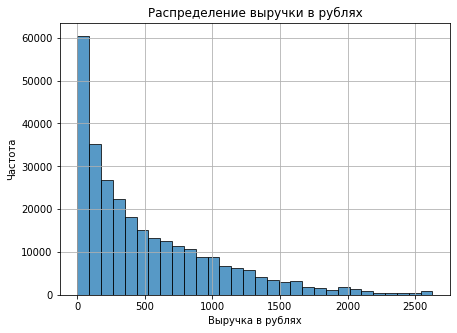

In [44]:
#Создадим гистограмму для столбца revenue_rub
plt.figure(figsize=(7, 5))

df['revenue_rub'].plot(
                kind='hist',
                bins=30,
                alpha=0.75,
                edgecolor='black',
                rot=0
)

plt.title('Распределение выручки в рублях')
plt.xlabel('Выручка в рублях')
plt.ylabel('Частота')
plt.grid()

# Выводим график
plt.show()

Гистограмма скошена вправо и имеет длинный хвост.
На основании графика можно сделать вывод, что самое большое количество операций не превышают выручку в 100 рублей.

In [45]:
df.loc[df['revenue_rub'] <=100]

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,service_name,event_type_main,region_name,city_name,revenue_rub
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.490000,2,0,387271,2f638715-8844-466c-b43f-378a627c419f,лови билет!,другое,Североярская область,Озёрск,8.490000
7,000a55a418c128c,mobile,4657981,2024-09-29,2024-09-29 19:39:12,rub,47.779999,1,0,265857,0d876e01-851e-458b-ba61-753e0e0c4063,лучшие билеты,театр,Поленовский край,Дальнозолотск,47.779999
8,000a55a418c128c,mobile,4657952,2024-10-15,2024-10-15 10:29:04,rub,74.839996,2,16,271579,ddc795f8-7ef8-4eb0-b299-cb3e6ee24ba1,лучшие билеты,театр,Поленовский край,Дальнозолотск,74.839996
24,0018ecd8a38a51b,mobile,3253250,2024-07-25,2024-07-25 20:38:57,rub,0.000000,3,0,548041,102fa659-6ca3-4a78-a0a4-20a0339679b5,билеты без проблем,спорт,Медовская область,Радужсвет,0.000000
52,002ec276eee9b0b,mobile,1573425,2024-08-28,2024-08-28 20:32:54,rub,96.790001,5,0,528066,96b2f4d5-a738-4ffa-a581-4f0984edbe9a,билеты в руки,театр,Ягодиновская область,Речинцево,96.790001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290564,ffed3ff067d4f12,mobile,6207248,2024-10-17,2024-10-17 21:41:59,rub,63.000000,3,0,584923,b8bf4ede-0b63-452d-a734-b61301b6ecfa,лучшие билеты,другое,Малиновая область,Сарыжар,63.000000
290572,fff13b79bd47d7c,mobile,3285933,2024-10-07,2024-10-07 09:13:26,rub,78.099998,1,9,554694,787d61f0-d0fa-4f32-97b4-e0079b51b6b0,билеты без проблем,концерты,Североярская область,Озёрск,78.099998
290592,fffcd3dde79eb2c,desktop,1012478,2024-08-30,2024-08-30 16:12:10,rub,36.509998,2,6,542199,094241a6-aedc-47ad-bfa9-89c2a6cd9d07,билеты без проблем,другое,Североярская область,Озёрск,36.509998
290596,fffcd3dde79eb2c,mobile,8019342,2024-09-12,2024-09-12 14:46:27,rub,10.530000,1,0,384441,108c5bfa-b11e-47ac-a482-d0e76702508e,лови билет!,другое,Североярская область,Озёрск,10.530000


In [46]:
# проверим статистические показатели столбца tickets_count
df['tickets_count'].describe()

count    287405.000000
mean          2.741323
std           1.163087
min           1.000000
25%           2.000000
50%           3.000000
75%           3.000000
max          57.000000
Name: tickets_count, dtype: float64

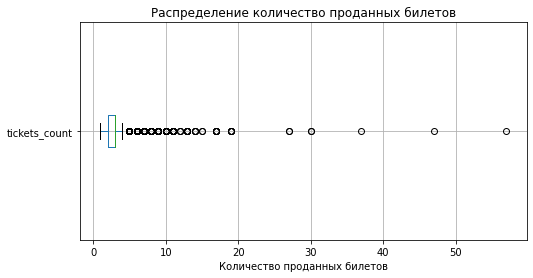

In [47]:
#Создадим диаграмму размаха значений в столбце tickets_count
plt.figure(figsize=(8, 4))

df.boxplot(column='tickets_count', vert=False)

plt.title('Распределение количество проданных билетов')
plt.xlabel('Количество проданных билетов')

plt.show()

Распределение количества проданных билетов асимметричное, скошенное вправо. Минимальное количество проданных билетов — 1, что является корректным и нормальным значением, а максимальное — 57, что может говорить о наличии выбросов, потому что 75% значений не превышают значение проданных билетов 3. Среднее значение - 2,7, а медиана — 3, что почти равно среднему значению.

По диаграмме размаха можно заметить, что основное количество значений не превышает примерно 16 билетов, проверим количество строк, количество проданных билетов в которых превышает 16, и по результатам примем решение, можно их удалить или нет.

In [48]:
df.loc[df['tickets_count'] > 16]

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,service_name,event_type_main,region_name,city_name,revenue_rub
39413,18e9aead0a393e7,desktop,5338292,2024-09-09,2024-09-09 10:03:45,rub,640.409973,47,0,561027,a8f27570-50ca-4ff2-9550-8a5493a335a6,билеты без проблем,спорт,Чистогорская область,Леснойск,640.409973
86251,3ee7dc2e115847f,desktop,5190653,2024-10-06,2024-10-06 13:06:40,rub,328.489990,27,0,575780,eaad35f5-f733-4ab1-a671-e7e86b2748c7,лови билет!,спорт,Озернинский край,Лесоярич,328.489990
86253,3ee7dc2e115847f,desktop,5190682,2024-10-06,2024-10-06 13:08:42,rub,328.489990,27,0,575780,eaad35f5-f733-4ab1-a671-e7e86b2748c7,лови билет!,спорт,Озернинский край,Лесоярич,328.489990
142917,76694a971889caa,desktop,1427845,2024-10-18,2024-10-18 09:59:15,rub,179.639999,17,5,542512,b92cc6f5-b351-4c1b-8a50-c232121dca14,билеты без проблем,другое,Речицкая область,Радужанов,179.639999
153327,7eb4fc207ecc10f,desktop,806230,2024-07-19,2024-07-19 17:21:09,rub,1723.900024,17,0,516731,2ccf2683-25a2-4eeb-92f7-d454019a9f30,мой билет,театр,Каменевский регион,Глиногорск,1723.900024
153329,7eb4fc207ecc10f,desktop,806259,2024-07-19,2024-07-19 17:06:30,rub,1926.709961,19,0,516731,2ccf2683-25a2-4eeb-92f7-d454019a9f30,мой билет,театр,Каменевский регион,Глиногорск,1926.709961
153332,7eb4fc207ecc10f,desktop,806288,2024-07-19,2024-07-19 16:34:49,rub,1723.900024,17,0,516731,2ccf2683-25a2-4eeb-92f7-d454019a9f30,мой билет,театр,Каменевский регион,Глиногорск,1723.900024
153335,7eb4fc207ecc10f,desktop,806143,2024-07-19,2024-07-19 17:13:59,rub,1926.709961,19,0,516731,2ccf2683-25a2-4eeb-92f7-d454019a9f30,мой билет,театр,Каменевский регион,Глиногорск,1926.709961
153337,7eb4fc207ecc10f,desktop,806114,2024-07-19,2024-07-19 16:51:50,rub,1723.900024,17,0,516731,2ccf2683-25a2-4eeb-92f7-d454019a9f30,мой билет,театр,Каменевский регион,Глиногорск,1723.900024
154001,7eb4fc207ecc10f,desktop,3526517,2024-08-22,2024-08-22 11:23:50,rub,0.000000,57,1,557574,05e7dbd5-b93a-4e31-9796-e9cce6741794,билеты без проблем,другое,Каменевский регион,Глиногорск,0.000000


Всего таких строк 18, при чем в нескольких из них сумма выручки равна нулю, либо показатели выручки не являются высокими, а также почти все заказы являются единичными, поэтому не представляют существенной ценности для целей анализа.
Удалим такие строки из датасета.

In [49]:
df = df.loc[df['tickets_count'] <=16]
df

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,service_name,event_type_main,region_name,city_name,revenue_rub
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.939941,4,0,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,край билетов,театр,Каменевский регион,Глиногорск,1521.939941
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.450012,2,0,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,мой билет,выставки,Каменевский регион,Глиногорск,289.450012
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.569946,4,75,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,за билетом!,другое,Каменевский регион,Глиногорск,1258.569946
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.490000,2,0,387271,2f638715-8844-466c-b43f-378a627c419f,лови билет!,другое,Североярская область,Озёрск,8.490000
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.410034,3,83,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,билеты без проблем,стендап,Озернинский край,Родниковецк,1390.410034
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290606,fffcd3dde79eb2c,mobile,368591,2024-10-27,2024-10-27 17:54:52,rub,965.570007,4,0,33189,e3dcdb45-9eaa-4ce4-9b85-1562e548172e,весь в билетах,другое,Каменевский регион,Глиногорск,965.570007
290607,fffcd3dde79eb2c,mobile,368562,2024-10-27,2024-10-27 17:53:53,rub,1448.359985,6,0,33189,e3dcdb45-9eaa-4ce4-9b85-1562e548172e,весь в билетах,другое,Каменевский регион,Глиногорск,1448.359985
290608,fffcd3dde79eb2c,desktop,8473772,2024-10-30,2024-10-30 13:37:43,rub,178.949997,2,3,205231,74883818-57a6-494a-b162-bb0260877cbf,прачечная,театр,Каменевский регион,Глиногорск,178.949997
290609,fffeeb3c120cf0b,desktop,5526067,2024-09-24,2024-09-24 10:07:42,rub,661.530029,2,0,454526,6f4c6a50-0106-407b-8f54-332c740b01da,билеты без проблем,стендап,Широковская область,Ягодиновка,661.530029


In [50]:
# снова проверим статистические показатели столбца revenue_rub
df['tickets_count'].describe()

count    287387.000000
mean          2.739922
std           1.146124
min           1.000000
25%           2.000000
50%           3.000000
75%           3.000000
max          15.000000
Name: tickets_count, dtype: float64

Среднее значение и медиана не изменились, но максимальное количество проданных билетов существенно уменьшилось.

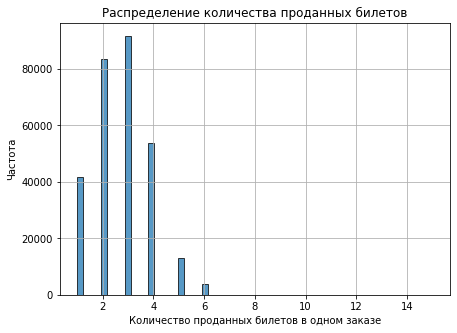

In [51]:
#Создадим гистограмму для столбца tickets_count
plt.figure(figsize=(7, 5))

df['tickets_count'].plot(
                kind='hist',
                bins=60,
                alpha=0.75,
                edgecolor='black',
                rot=0
)

plt.title('Распределение количества проданных билетов')
plt.xlabel('Количество проданных билетов в одном заказе')
plt.ylabel('Частота')
plt.grid()

# Выводим график
plt.show()

Гистограмма выглядит более-менее симметричной, при этом она чуть скошена вправо и имеет небольшой хвост.
По ней видно, что самое частое количество продаваемых билетов находится в районе 3.

In [52]:
# снова выводим информацию о датасете
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 287387 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                287387 non-null  object        
 1   device_type_canonical  287387 non-null  object        
 2   order_id               287387 non-null  int32         
 3   order_dt               287387 non-null  datetime64[ns]
 4   order_ts               287387 non-null  datetime64[ns]
 5   currency_code          287387 non-null  object        
 6   revenue                287387 non-null  float32       
 7   tickets_count          287387 non-null  int8          
 8   days_since_prev        287387 non-null  int16         
 9   event_id               287387 non-null  int32         
 10  event_name             287387 non-null  object        
 11  service_name           287387 non-null  object        
 12  event_type_main        287387 non-null  obje

На момент знакомства с данными в датасете было **290611** строк.

В результате предобработки данных были выполнены следующие действия:
- Оптимизированы типы данных integer и float в числовых столбцах.
- Изучены пропуски в данных. Пропуски обнаружены только в столбце `days_since_prev`, они появились в результате расчета дней между заказами пользователями и означают, что у пользователя не было предыдущего заказа. Было принято решение заменить значения на 0.
- Был создан новый столбец `revenue_rub`, в котором мы рассчитали выручку в рублях для операций в казахстанских тенге по курсу даты операции.
- Проверены номинальные, категориальные столбцы, аномальные названия категорий, городов, регионов не найдены. Значения, которую могут обозначать пропуски, в таких столбцах отсутствуют.
- Проверены числовые столбцы `revenue_rub` и `tickets_count`, в обоих столбцах были обнаружены выбросы, а также были выявлены аномальные отрицательные значения выручки в рублях. По результатам было удалено **381** строк с отрицательными значениями выручки, а также суммарно **2843** строк, связанных с выбросами в обоих столбцах.

Таким образом, после всех действий по предобработке данных в датасете осталось **287387** строк.

---

## 3. Создание профиля пользователя

---

**Задача 3.1.** Построим профиль пользователя — для каждого пользователя найдем:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия;
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

Затем добавим два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.
---


In [53]:
# отсортируем датасет по пользователям и времени совершения заказа
df_sorted = df.sort_values(by = ['user_id', 'order_ts'])
df_sorted

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,service_name,event_type_main,region_name,city_name,revenue_rub
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.939941,4,0,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,край билетов,театр,Каменевский регион,Глиногорск,1521.939941
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.450012,2,0,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,мой билет,выставки,Каменевский регион,Глиногорск,289.450012
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.569946,4,75,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,за билетом!,другое,Каменевский регион,Глиногорск,1258.569946
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.490000,2,0,387271,2f638715-8844-466c-b43f-378a627c419f,лови билет!,другое,Североярская область,Озёрск,8.490000
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.410034,3,83,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,билеты без проблем,стендап,Озернинский край,Родниковецк,1390.410034
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290606,fffcd3dde79eb2c,mobile,368591,2024-10-27,2024-10-27 17:54:52,rub,965.570007,4,0,33189,e3dcdb45-9eaa-4ce4-9b85-1562e548172e,весь в билетах,другое,Каменевский регион,Глиногорск,965.570007
290605,fffcd3dde79eb2c,mobile,368620,2024-10-27,2024-10-27 18:00:57,rub,965.570007,4,1,33189,e3dcdb45-9eaa-4ce4-9b85-1562e548172e,весь в билетах,другое,Каменевский регион,Глиногорск,965.570007
290608,fffcd3dde79eb2c,desktop,8473772,2024-10-30,2024-10-30 13:37:43,rub,178.949997,2,3,205231,74883818-57a6-494a-b162-bb0260877cbf,прачечная,театр,Каменевский регион,Глиногорск,178.949997
290609,fffeeb3c120cf0b,desktop,5526067,2024-09-24,2024-09-24 10:07:42,rub,661.530029,2,0,454526,6f4c6a50-0106-407b-8f54-332c740b01da,билеты без проблем,стендап,Широковская область,Ягодиновка,661.530029


In [54]:
# создадим профиль пользователя и в первую очередь добавим столбцы с агрегацией по пользователям
user_profile = df.groupby('user_id').agg({'order_dt': ['min','max'], 'order_id': 'count', 
                                        'revenue_rub': 'mean','tickets_count': 'mean','days_since_prev': 'mean'})
user_profile

order_dt            order_id  revenue_rub tickets_count  \
                       min        max    count         mean          mean   
user_id                                                                     
0002849b70a3ce2 2024-08-20 2024-08-20        1  1521.939941      4.000000   
0005ca5e93f2cf4 2024-07-23 2024-10-06        2   774.010010      3.000000   
000898990054619 2024-07-13 2024-10-23        3   767.213318      2.666667   
00096d1f542ab2b 2024-08-15 2024-08-15        1   917.830017      4.000000   
000a55a418c128c 2024-09-29 2024-10-15        2    61.309998      1.500000   
...                    ...        ...      ...          ...           ...   
fff13b79bd47d7c 2024-07-16 2024-10-31        9   688.043335      2.555556   
fff32fc9ad0f9f6 2024-08-15 2024-10-28        2   850.994995      2.500000   
fffcd3dde79eb2c 2024-06-20 2024-10-30       33   557.908508      2.787879   
fffeeb3c120cf0b 2024-09-24 2024-09-24        1   661.530029      2.000000   
ffff00725179321 2024-09-25 2024-09-25        1   802.250000      2.000000   

                days_since_prev  
                           mean  
user_id                          
0002849b70a3ce2        0.000000  
0005ca5e93f2cf4       37.500000  
000898990054619       34.000000  
00096d1f542ab2b        0.000000  
000a55a418c128c        8.000000  
...                         ...  
fff13b79bd47d7c       11.888889  
fff32fc9ad0f9f6       37.000000  
fffcd3dde79eb2c        4.000000  
fffeeb3c120cf0b        0.000000  
ffff00725179321        0.000000  

[21838 rows x 6 columns]

In [55]:
# переименуем созданные столбцы и установим заново индекс
user_profile.columns = ['first_order_dt','last_order_dt','orders_count','avg_revenue_rub','avg_tickets_count',
                       'avg_days_since_prev']
user_profile = user_profile.reset_index()
user_profile


,user_id,first_order_dt,last_order_dt,orders_count,avg_revenue_rub,avg_tickets_count,avg_days_since_prev
0,0002849b70a3ce2,2024-08-20,2024-08-20,1,1521.939941,4.000000,0.000000
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,2,774.010010,3.000000,37.500000
2,000898990054619,2024-07-13,2024-10-23,3,767.213318,2.666667,34.000000
3,00096d1f542ab2b,2024-08-15,2024-08-15,1,917.830017,4.000000,0.000000
4,000a55a418c128c,2024-09-29,2024-10-15,2,61.309998,1.500000,8.000000
...,...,...,...,...,...,...,...
21833,fff13b79bd47d7c,2024-07-16,2024-10-31,9,688.043335,2.555556,11.888889
21834,fff32fc9ad0f9f6,2024-08-15,2024-10-28,2,850.994995,2.500000,37.000000
21835,fffcd3dde79eb2c,2024-06-20,2024-10-30,33,557.908508,2.787879,4.000000
21836,fffeeb3c120cf0b,2024-09-24,2024-09-24,1,661.530029,2.000000,0.000000


In [56]:
# оставим только первые строки пользователей и присоединим их к нашему профилю пользователя
first_orders = df.drop_duplicates('user_id',keep = 'first')

user_profile = user_profile.merge(first_orders[['user_id','device_type_canonical','region_name','service_name',
                                                'event_type_main']],on = 'user_id')
user_profile

,user_id,first_order_dt,last_order_dt,orders_count,avg_revenue_rub,avg_tickets_count,avg_days_since_prev,device_type_canonical,region_name,service_name,event_type_main
0,0002849b70a3ce2,2024-08-20,2024-08-20,1,1521.939941,4.000000,0.000000,mobile,Каменевский регион,край билетов,театр
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,2,774.010010,3.000000,37.500000,mobile,Каменевский регион,мой билет,выставки
2,000898990054619,2024-07-13,2024-10-23,3,767.213318,2.666667,34.000000,mobile,Североярская область,лови билет!,другое
3,00096d1f542ab2b,2024-08-15,2024-08-15,1,917.830017,4.000000,0.000000,desktop,Каменевский регион,край билетов,театр
4,000a55a418c128c,2024-09-29,2024-10-15,2,61.309998,1.500000,8.000000,mobile,Поленовский край,лучшие билеты,театр
...,...,...,...,...,...,...,...,...,...,...,...
21833,fff13b79bd47d7c,2024-07-16,2024-10-31,9,688.043335,2.555556,11.888889,mobile,Каменевский регион,мой билет,другое
21834,fff32fc9ad0f9f6,2024-08-15,2024-10-28,2,850.994995,2.500000,37.000000,desktop,Каменевский регион,билеты без проблем,стендап
21835,fffcd3dde79eb2c,2024-06-20,2024-10-30,33,557.908508,2.787879,4.000000,desktop,Каменевский регион,билеты без проблем,концерты
21836,fffeeb3c120cf0b,2024-09-24,2024-09-24,1,661.530029,2.000000,0.000000,desktop,Широковская область,билеты без проблем,стендап


In [57]:
# создадим два новых столбца с бинарными признаками
user_profile['is_two'] = (user_profile['orders_count'] >=2).astype(int)
user_profile['is_five'] = (user_profile['orders_count'] >=5).astype(int)
user_profile

,user_id,first_order_dt,last_order_dt,orders_count,avg_revenue_rub,avg_tickets_count,avg_days_since_prev,device_type_canonical,region_name,service_name,event_type_main,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,1,1521.939941,4.000000,0.000000,mobile,Каменевский регион,край билетов,театр,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,2,774.010010,3.000000,37.500000,mobile,Каменевский регион,мой билет,выставки,1,0
2,000898990054619,2024-07-13,2024-10-23,3,767.213318,2.666667,34.000000,mobile,Североярская область,лови билет!,другое,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15,1,917.830017,4.000000,0.000000,desktop,Каменевский регион,край билетов,театр,0,0
4,000a55a418c128c,2024-09-29,2024-10-15,2,61.309998,1.500000,8.000000,mobile,Поленовский край,лучшие билеты,театр,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21833,fff13b79bd47d7c,2024-07-16,2024-10-31,9,688.043335,2.555556,11.888889,mobile,Каменевский регион,мой билет,другое,1,1
21834,fff32fc9ad0f9f6,2024-08-15,2024-10-28,2,850.994995,2.500000,37.000000,desktop,Каменевский регион,билеты без проблем,стендап,1,0
21835,fffcd3dde79eb2c,2024-06-20,2024-10-30,33,557.908508,2.787879,4.000000,desktop,Каменевский регион,билеты без проблем,концерты,1,1
21836,fffeeb3c120cf0b,2024-09-24,2024-09-24,1,661.530029,2.000000,0.000000,desktop,Широковская область,билеты без проблем,стендап,0,0


---

**Задача 3.2.**
Используя данные о профилях пользователей, рассчитаем:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучим статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

In [58]:
# рассчитаем общее число пользователей в датасете с профилем пользователя
users_count = len(user_profile['user_id'])
users_count

21838

In [59]:
# рассчитаем среднюю выручку с одного заказа
avg_revenue_rub_per_order = df['revenue_rub'].mean()
avg_revenue_rub_per_order 

518.70953

In [60]:
# рассчитаем долю пользователей, совершивших 2 и более заказа
is_two_share = user_profile['is_two'].mean()
is_two_share

0.6170436853191684

In [61]:
# рассчитаем долю пользователей, совершивших 5 и более заказов
is_five_share = user_profile['is_five'].mean()
is_five_share

0.28995329242604634

Получается, что количество пользователей в выборке - 21838, средняя выручка в рублях на заказ - 518,71 руб.,
доля пользователей, совершивших 2 и более заказа - 61,7%, доля пользователей, совершивших 5 и более заказов - 29%.

In [62]:
# проверяем статистику по общему числу заказов
user_profile['orders_count'].describe()

count    21838.000000
mean        13.159951
std        121.557551
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max      10168.000000
Name: orders_count, dtype: float64

Среднее значение (13) сильно отличается от медианы (2), потому что в данных есть выбросы и огромное значение  максимального количества заказов на одного пользователя - 10168. Это похоже на ошибку данных или на тестовый аккаунт.

In [63]:
# проверяем статистику по среднему числу билетов в заказе
user_profile['avg_tickets_count'].describe()

count    21838.000000
mean         2.743829
std          0.912218
min          1.000000
25%          2.000000
50%          2.750000
75%          3.080000
max         11.000000
Name: avg_tickets_count, dtype: float64

Статистика выглядит нормально, без аномалий. Среднее значение (2,74) соответствует медиане (2,75).

In [64]:
# проверяем статистику по среднему количеству дней между покупками
user_profile['avg_days_since_prev'].describe()

count    21838.000000
mean         6.556578
std         11.121521
min          0.000000
25%          0.000000
50%          0.000000
75%          9.428571
max        137.000000
Name: avg_days_since_prev, dtype: float64

На первый взгляд в данных есть выбросы, так как среднее значение (6,56) сильно отличается от медианы (0).
Но такие данные выглядят реальными, поскольку много пользователей совершили заказ всего один раз, а максимальное значение 137 дней имеет место быть.

Таким образом, следует более детально изучить и при необходимости отфильтровать только столбец `order_count`.

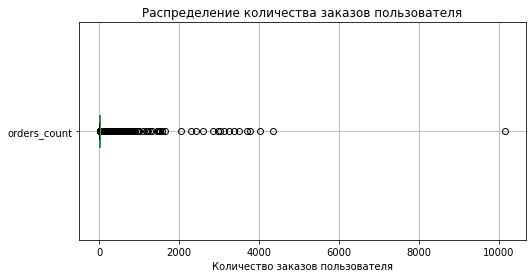

In [65]:
# построим диаграмму размаха
plt.figure(figsize=(8, 4))

user_profile.boxplot(column='orders_count', vert=False)

plt.title('Распределение количества заказов пользователя')
plt.xlabel('Количество заказов пользователя')

plt.show()

In [66]:
# вычисляем 95 и 99 процентили
quan_95_user_profile = user_profile['orders_count'].quantile(0.95)
quan_99_user_profile = user_profile['orders_count'].quantile(0.99)
print(quan_95_user_profile)
quan_99_user_profile

31.0


152.0

In [67]:
# проверим, сколько строк превышают 95 процентиль
user_profile.loc[user_profile['orders_count'] > quan_95_user_profile]

,user_id,first_order_dt,last_order_dt,orders_count,avg_revenue_rub,avg_tickets_count,avg_days_since_prev,device_type_canonical,region_name,service_name,event_type_main,is_two,is_five
78,00f4f5244501ce6,2024-06-16,2024-10-30,42,961.873596,2.880952,3.357143,mobile,Озернинский край,билеты в руки,концерты,1,1
87,00fcd3ab0e5c558,2024-06-06,2024-10-31,39,465.851288,2.897436,3.769231,mobile,Тепляковская область,облачко,концерты,1,1
106,01370a0e9c1a7d5,2024-06-01,2024-10-31,152,520.989319,2.750000,1.000000,mobile,Лесодальний край,прачечная,театр,1,1
130,0186f6e000b581c,2024-06-08,2024-10-31,52,615.969971,2.865385,2.788462,mobile,Малиновоярский округ,show_ticket,концерты,1,1
137,019fa401ddb00aa,2024-06-01,2024-10-31,667,463.077545,2.694153,0.223388,mobile,Горицветская область,билеты без проблем,театр,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21753,ff0d86940a3fe67,2024-07-20,2024-10-30,52,93.974617,2.326923,1.961538,mobile,Каменевский регион,билеты в руки,стендап,1,1
21765,ff3c5654070575e,2024-06-06,2024-10-29,58,382.731903,2.413793,2.103448,mobile,Травяная область,билеты в руки,концерты,1,1
21780,ff684621b134cc4,2024-06-04,2024-10-31,101,633.692078,2.475248,1.465347,desktop,Каменевский регион,дом культуры,концерты,1,1
21798,ff9310a90294d5c,2024-06-21,2024-10-31,53,476.232452,2.433962,2.490566,mobile,Светополянский округ,яблоко,театр,1,1


In [68]:
# проверим, сколько строк превышают 99 процентиль
user_profile.loc[user_profile['orders_count'] > quan_99_user_profile]

,user_id,first_order_dt,last_order_dt,orders_count,avg_revenue_rub,avg_tickets_count,avg_days_since_prev,device_type_canonical,region_name,service_name,event_type_main,is_two,is_five
137,019fa401ddb00aa,2024-06-01,2024-10-31,667,463.077545,2.694153,0.223388,mobile,Горицветская область,билеты без проблем,театр,1,1
188,024dc5236465850,2024-06-01,2024-10-31,1168,520.425232,2.819349,0.129281,mobile,Североярская область,реестр,концерты,1,1
235,02ea4583333f064,2024-06-01,2024-10-31,2978,575.359802,2.716924,0.050369,mobile,Травяная область,билеты в руки,другое,1,1
317,03dfd23ba7c058e,2024-06-03,2024-10-31,294,558.189087,2.721088,0.510204,mobile,Североярская область,билеты в руки,другое,1,1
346,043f669c9f734b1,2024-06-01,2024-10-31,1483,514.971741,2.656777,0.101821,mobile,Каменевский регион,билеты без проблем,другое,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21366,fa855563e6939e7,2024-06-01,2024-10-31,157,425.624023,2.700637,0.961783,desktop,Озернинский край,билеты без проблем,концерты,1,1
21527,fc950d43881de43,2024-06-01,2024-10-31,1559,552.077576,2.713278,0.096216,mobile,Североярская область,мой билет,другое,1,1
21565,fce8b5e7ceaf416,2024-06-01,2024-10-31,294,491.985687,2.591837,0.513605,desktop,Североярская область,городской дом культуры,театр,1,1
21600,fd4d47438ebb946,2024-06-01,2024-10-31,1093,589.743347,2.697164,0.137237,mobile,Широковская область,прачечная,театр,1,1


По диаграмме размаха видно, что выбросами можно считать количество заказов, превышающее 2000, поэтому отфильтруем профиль пользователя по 99 процентилю.

In [69]:
user_profile = user_profile.loc[user_profile ['orders_count'] <= quan_99_user_profile]
user_profile

,user_id,first_order_dt,last_order_dt,orders_count,avg_revenue_rub,avg_tickets_count,avg_days_since_prev,device_type_canonical,region_name,service_name,event_type_main,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,1,1521.939941,4.000000,0.000000,mobile,Каменевский регион,край билетов,театр,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,2,774.010010,3.000000,37.500000,mobile,Каменевский регион,мой билет,выставки,1,0
2,000898990054619,2024-07-13,2024-10-23,3,767.213318,2.666667,34.000000,mobile,Североярская область,лови билет!,другое,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15,1,917.830017,4.000000,0.000000,desktop,Каменевский регион,край билетов,театр,0,0
4,000a55a418c128c,2024-09-29,2024-10-15,2,61.309998,1.500000,8.000000,mobile,Поленовский край,лучшие билеты,театр,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21833,fff13b79bd47d7c,2024-07-16,2024-10-31,9,688.043335,2.555556,11.888889,mobile,Каменевский регион,мой билет,другое,1,1
21834,fff32fc9ad0f9f6,2024-08-15,2024-10-28,2,850.994995,2.500000,37.000000,desktop,Каменевский регион,билеты без проблем,стендап,1,0
21835,fffcd3dde79eb2c,2024-06-20,2024-10-30,33,557.908508,2.787879,4.000000,desktop,Каменевский регион,билеты без проблем,концерты,1,1
21836,fffeeb3c120cf0b,2024-09-24,2024-09-24,1,661.530029,2.000000,0.000000,desktop,Широковская область,билеты без проблем,стендап,0,0


In [70]:
user_profile.describe()

,orders_count,avg_revenue_rub,avg_tickets_count,avg_days_since_prev,is_two,is_five
count,21622.000000,21622.000000,21622.000000,21622.000000,21622.000000,21622.000000
mean,6.496439,545.354248,2.744025,6.617510,0.613218,0.282860
std,14.310273,433.550659,0.916622,11.160098,0.487024,0.450399
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,1.000000,211.057495,2.000000,0.000000,0.000000,0.000000
50%,2.000000,464.656601,2.750000,0.000000,1.000000,0.000000
75%,5.000000,768.598770,3.100000,9.500000,1.000000,1.000000
max,152.000000,2628.421631,11.000000,137.000000,1.000000,1.000000


Мы удалили 216 строк из датасета с профилем пользователя, количество клиентов снизилось до 21622.
В столбце `orders_count` среднее значение тоже снизилось и составило 6,5 заказов на одного клиента.

---

## 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используем профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

**Задача 4.1.1.** Изучим распределение пользователей по признакам.

- Сгруппируем пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитаем общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. 

In [71]:
# сгруппируем пользователей по типу первого мероприятия, определим их количество в каждом сегменте и долю
segment_first_event = user_profile.groupby('event_type_main')['user_id'].count().reset_index()
segment_first_event['share'] = (segment_first_event['user_id']/len(user_profile))
segment_first_event.sort_values(by='user_id', ascending = False)

,event_type_main,user_id,share
2,концерты,9565,0.442374
1,другое,5407,0.250069
5,театр,4230,0.195634
4,стендап,1111,0.051383
3,спорт,799,0.036953
0,выставки,415,0.019193
6,ёлки,95,0.004394


In [72]:
# сгруппируем пользователей по типу устройства в первом заказе, определим их количество в каждом сегменте и долю
segment_first_device = user_profile.groupby('device_type_canonical')['user_id'].count().reset_index()
segment_first_device['share'] = (segment_first_device['user_id']/len(user_profile))
segment_first_device.sort_values(by='user_id', ascending = False)

,device_type_canonical,user_id,share
1,mobile,17883,0.827074
0,desktop,3739,0.172926


In [73]:
# сгруппируем пользователей по региону мероприятия в первом заказе, определим их количество в каждом сегменте и долю
segment_first_region = user_profile.groupby('region_name')['user_id'].count().reset_index()
segment_first_region['share'] = (segment_first_region['user_id']/len(user_profile))
segment_first_region.sort_values(by='user_id', ascending = False)

,region_name,user_id,share
23,Каменевский регион,7089,0.327861
60,Североярская область,3766,0.174174
77,Широковская область,1221,0.056470
45,Озернинский край,677,0.031311
41,Малиновоярский округ,527,0.024373
...,...,...,...
17,Залесский край,2,0.000092
70,Тихогорская область,2,0.000092
5,Верхозёрский край,1,0.000046
66,Сосноводолинская область,1,0.000046


Верхозёрский край	1.000000
46	Озернопольская область	0.896552
51	Радужнопольский край	0.791667
36	Лесостепной край	0.716667
71	Тихолесский край	0.700000
12	Горноземский регион	0.689655
76	Шанырский регион	0.672000
79	Ягодиновская область	0.671875
33	Лесноярский край	0.666667
4	Верховинская область	0.666667


In [74]:
# сгруппируем пользователей по билетному оператору в первом заказе, определим их количество в каждом сегменте и долю
segment_first_service = user_profile.groupby('service_name')['user_id'].count().reset_index()
segment_first_service['share'] = (segment_first_service['user_id']/len(user_profile))
segment_first_service.sort_values(by='user_id', ascending = False)

,service_name,user_id,share
3,билеты без проблем,5153,0.238322
22,мой билет,2974,0.137545
19,лови билет!,2808,0.129868
4,билеты в руки,2562,0.118490
23,облачко,2179,0.100777
7,весь в билетах,1279,0.059153
20,лучшие билеты,1189,0.054990
24,прачечная,581,0.026871
17,край билетов,454,0.020997
12,дом культуры,356,0.016465


Сгруппировав пользоваталей по указанным признакам, мы определили, что:
- почти у половины пользователей (44%) первое приобретенное мероприятие - концерты, на втором месте - другие мероприятия (25%), на третьем - театр (20%). На остальные типы мероприятий приходится всего 11%;
- подавляющее число пользователей (87%) совершили первые покупки через мобильные устройства, остальные 13% - с использованием стационарных компьютеров;
- у половины пользователей регионами проведения мероприятия из первого заказа являются Каменевский регион (33%) и Североярская область	(17%);
- почти четверть пользователей (24%) совершили первые покупки через билетного оператора 'Билеты без проблем', также лидирующие занимают 'Мой билет' (14%) и 'Лови билет!' (13%).

---

**Задача 4.1.2.** Проанализируем возвраты пользователей:

- Для каждого сегмента вычислим долю пользователей, совершивших два и более заказа.
- Визуализируем результат подходящим графиком. 


In [75]:
# # рассчитаем среднее значение по доле пользователей, совершивших два и более заказа
mean_is_two_share = user_profile['is_two'].mean()

In [76]:
# вычислим долю пользователей, совершивших два и более заказа, в отношении сегмента мероприятий первого заказа
segment_event_is_two = user_profile.groupby('event_type_main')['is_two'].mean().reset_index()
segment_event_is_two.sort_values(by='is_two', ascending = False)

,event_type_main,is_two
0,выставки,0.643373
5,театр,0.633097
2,концерты,0.618191
4,стендап,0.609361
1,другое,0.596079
3,спорт,0.560701
6,ёлки,0.557895


<Figure size 720x432 with 0 Axes>

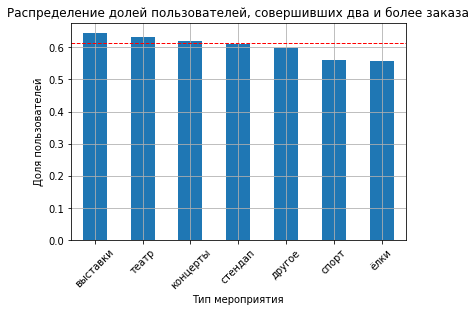

In [77]:
# Построим столбчатую диаграмму и нанесем на график линию с средним значением доли пользователей
plt.figure(figsize=(10, 6))

segment_event_is_two.sort_values(by='is_two', ascending = False).plot(
               kind='bar',
               rot=45,
               legend=False,
               x='event_type_main',
               y='is_two',
               title=f'Распределение долей пользователей, совершивших два и более заказа'
)

plt.axhline(mean_is_two_share, 
            color='red', 
            linestyle='--', 
            linewidth=1, 
            label=f'Доля пользователей, совершивших два и более заказа {round(mean_is_two_share,4)}')

plt.xlabel('Тип мероприятия')
plt.ylabel('Доля пользователей')
plt.grid()

plt.show()

На диаграмме видно, что доли вернувшихся пользователей примерно одинаковы для всех типов мероприятий из первых заказов пользователей. Покупатели выставок чаще всего (в 64% случаев) возвращаются в Яндекс Афишу, однако этот сегмент представлен небольшим количеством пользователей, поэтому результат может быть нерепрезентативен.
Мероприятия типов "выставки", "театр", "концерты" являются точками входа, пользователи чаще совершают повторный заказ, чем в среднем по выборке.

In [78]:
# вычислим долю пользователей, совершивших два и более заказа, в отношении сегмента устройств первого заказа
segment_device_is_two = user_profile.groupby('device_type_canonical')['is_two'].mean().reset_index()
segment_device_is_two.sort_values(by='is_two', ascending = False)

,device_type_canonical,is_two
0,desktop,0.640546
1,mobile,0.607504


<Figure size 720x432 with 0 Axes>

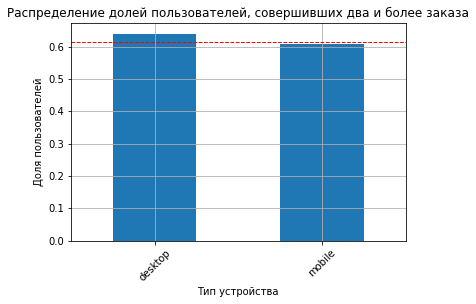

In [79]:
# Построим столбчатую диаграмму и нанесем на график линию с средним значением доли пользователей
plt.figure(figsize=(10, 6))

segment_device_is_two.sort_values(by='is_two', ascending = False).plot(
               kind='bar',
               rot=45,
               legend=False,
               x='device_type_canonical',
               y='is_two',
               title=f'Распределение долей пользователей, совершивших два и более заказа'
)

plt.axhline(mean_is_two_share, 
            color='red', 
            linestyle='--', 
            linewidth=1, 
            label=f'Доля пользователей, совершивших два и более заказа {round(mean_is_two_share,4)}')

plt.xlabel('Тип устройства')
plt.ylabel('Доля пользователей')
plt.grid()

plt.show()

Доли вернувшихся пользователей примерно одинаковы для обоих типов устройств. Пользователи мобильных устройств чаще всего (в 64% случаев) возвращаются в Яндекс Афишу, при этом это значение превышает среднее по выборке.

In [80]:
# вычислим долю пользователей, совершивших два и более заказа, в отношении сегмента региона первого заказа
segment_region_is_two = user_profile.groupby('region_name')['is_two'].mean().reset_index()
segment_region_is_two_top_ten = segment_region_is_two.sort_values(by='is_two', ascending = False).head(10)
segment_region_is_two_top_ten

,region_name,is_two
5,Верхозёрский край,1.000000
46,Озернопольская область,0.896552
51,Радужнопольский край,0.791667
36,Лесостепной край,0.716667
71,Тихолесский край,0.700000
12,Горноземский регион,0.689655
76,Шанырский регион,0.672000
79,Ягодиновская область,0.671875
33,Лесноярский край,0.666667
4,Верховинская область,0.666667


In [81]:
# выведем на экран 50 регионов с самым меньшим количеством пользователей  
segment_first_region.sort_values(by='user_id', ascending = False).tail(50)

,region_name,user_id,share
31,Крутоводская область,87,0.004024
43,Миропольская область,85,0.003931
14,Дальнеземская область,64,0.002960
79,Ягодиновская область,64,0.002960
63,Синегорский регион,62,0.002867
13,Горностепной регион,61,0.002821
36,Лесостепной край,60,0.002775
58,Североключевской округ,59,0.002729
55,Ручейковский край,55,0.002544
27,Каменополянский округ,53,0.002451


<Figure size 720x432 with 0 Axes>

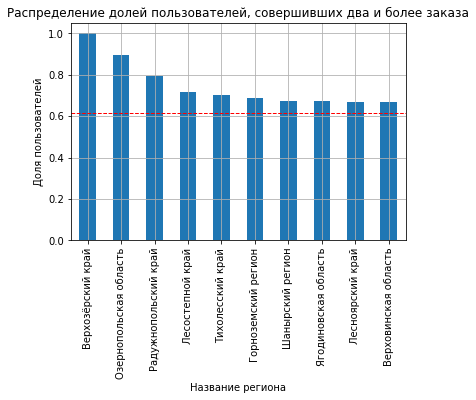

In [82]:
# Построим столбчатую диаграмму и нанесем на график линию с средним значением доли пользователей
plt.figure(figsize=(10, 6))

segment_region_is_two_top_ten.sort_values(by='is_two', ascending = False).plot(
               kind='bar',
               rot=90,
               legend=False,
               x='region_name',
               y='is_two',
               title=f'Распределение долей пользователей, совершивших два и более заказа'
)

plt.axhline(mean_is_two_share, 
            color='red', 
            linestyle='--', 
            linewidth=1, 
            label=f'Доля пользователей, совершивших два и более заказа {round(mean_is_two_share,4)}')

plt.xlabel('Название региона')
plt.ylabel('Доля пользователей')
plt.grid()

plt.show()

У всех 10 топ-регионов по наибольшим долям пользователей, совершивших два и более заказа, значения долей превышают среднее по выборке, однако все эти регионы содержат малое количество пользователей, поэтому результат может быть недостоверен.

In [83]:
# вычислим долю пользователей, совершивших два и более заказа, в отношении сегмента билетных операторов первого заказа
segment_service_is_two = user_profile.groupby('service_name')['is_two'].mean().reset_index()
segment_service_is_two_top_ten = segment_service_is_two.sort_values(by='is_two', ascending = False).head(10)
segment_service_is_two_top_ten

,service_name,is_two
14,зе бест!,1.000000
6,быстрый кассир,0.854839
2,билет по телефону,0.833333
26,реестр,0.812500
0,crazy ticket!,0.708333
8,восьмёрка,0.682353
1,show_ticket,0.654088
31,цвет и билет,0.652174
17,край билетов,0.651982
12,дом культуры,0.646067


In [84]:
# выведем на экран 15 операторов с самым меньшим количеством пользователей  
segment_first_service.sort_values(by='user_id', ascending = False).tail(15)

,service_name,user_id,share
6,быстрый кассир,62,0.002867
0,crazy ticket!,48,0.002220
27,росбилет,38,0.001757
25,радио ticket,36,0.001665
26,реестр,32,0.001480
29,телебилет,27,0.001249
31,цвет и билет,23,0.001064
32,шоу начинается!,19,0.000879
15,карандашру,15,0.000694
16,кино билет,9,0.000416


<Figure size 720x432 with 0 Axes>

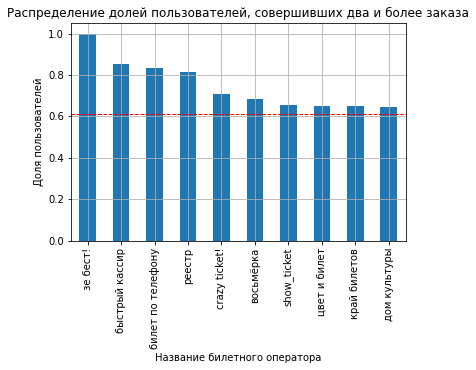

In [85]:
# Построим столбчатую диаграмму и нанесем на график линию с средним значением доли пользователей
plt.figure(figsize=(10, 6))

segment_service_is_two_top_ten.sort_values(by='is_two', ascending = False).plot(
               kind='bar',
               rot=90,
               legend=False,
               x='service_name',
               y='is_two',
               title=f'Распределение долей пользователей, совершивших два и более заказа'
)

plt.axhline(mean_is_two_share, 
            color='red', 
            linestyle='--', 
            linewidth=1, 
            label=f'Доля пользователей, совершивших два и более заказа {round(mean_is_two_share,4)}')

plt.xlabel('Название билетного оператора')
plt.ylabel('Доля пользователей')
plt.grid()

plt.show()

У всех 10 топ-операторов по наибольшим долям пользователей, совершивших два и более заказа, значения долей превышают среднее по выборке, однако топ-3 операторов ("Зе бест!", "Быстрый кассир" и "Билет по телефону") содержат малое количество пользователей, поэтому по ним результат может быть неинформативен.

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

In [86]:
# посчитаем долю возвратов для спортивных мероприятий
user_profile.groupby('event_type_main')['is_two'].mean().sort_values(ascending=False)

event_type_main
выставки    0.643373
театр       0.633097
концерты    0.618191
стендап     0.609361
другое      0.596079
спорт       0.560701
ёлки        0.557895
Name: is_two, dtype: float64

Гипотеза 1 не подтвердилась - пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ реже, чем пользователи, оформившие свой первый заказ на концерты.

In [87]:
# посчитаем долю возвратов для регионов
user_profile.groupby('event_type_main')['is_two'].mean().sort_values(ascending=False)

event_type_main
выставки    0.643373
театр       0.633097
концерты    0.618191
стендап     0.609361
другое      0.596079
спорт       0.560701
ёлки        0.557895
Name: is_two, dtype: float64

In [88]:
return_region = user_profile.groupby('region_name').agg({'user_id':'count','is_two':'mean'}).sort_values(by = 'user_id',
                                                                                         ascending=False)
print(return_region.to_string())

                           user_id    is_two
region_name                                 
Каменевский регион            7089  0.624065
Североярская область          3766  0.638078
Широковская область           1221  0.643735
Озернинский край               677  0.553914
Малиновоярский округ           527  0.559772
Шанырский регион               500  0.672000
Травяная область               487  0.613963
Светополянский округ           456  0.655702
Речиновская область            438  0.632420
Яблоневская область            411  0.593674
Верхоречная область            379  0.583113
Медовская область              376  0.595745
Лугоградская область           357  0.557423
Серебринская область           328  0.551829
Тепляковская область           319  0.589342
Солнечнореченская область      296  0.587838
Солнечноземская область        284  0.595070
Горицветская область           243  0.662551
Глиногорская область           217  0.534562
Зоринский регион               213  0.591549
Заречная о

Гипотеза 2 также не подтвердилась - активность региона не влияет на долю повторных заказов.

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучим количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

---

**Задача 4.2.1.** Проследим связь между средней выручкой сервиса с заказа и повторными заказами.

- Построим сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответим на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

---


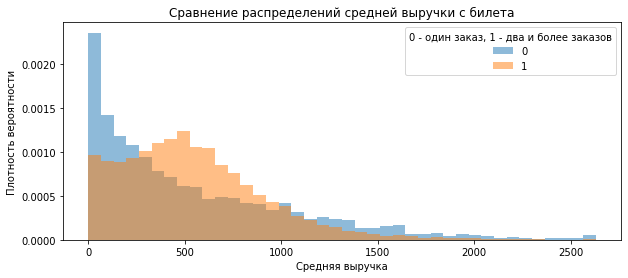

In [89]:
# построим гистограмму распределения средней выручки
plt.figure(figsize=(10, 4))

for i in user_profile['is_two'].unique():
    user_profile.loc[user_profile['is_two'] == i, 'avg_revenue_rub'].plot(
        kind='hist',
        density=True,
        bins=40,
        alpha=0.5,
        label=f'{i}',
        legend=True
    )

plt.title(f'Сравнение распределений средней выручки с билета')
plt.xlabel('Средняя выручка')
plt.ylabel('Плотность вероятности')
plt.legend(title='0 - один заказ, 1 - два и более заказов')
plt.show()

На графике видно, что распределение выборки для пользователей, совершивших один заказ, смещено в область нулевых значений выручки, тогда как для вернувшихся пользователей пик плотности приходится на значение в районе 500 рублей.
Можно сделать вывод, что пользователей с самыми маленькими заказами чаще совершают единичные заказы, так же, как и пользователи с самыми крупными заказами.

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


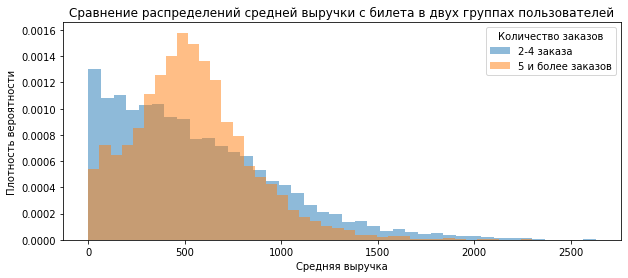

In [90]:
# построим гистограмму распределения средней выручки 
plt.figure(figsize=(10, 4))

user_profile.loc[(user_profile['is_two'] == 1) & (user_profile['is_five'] == 0), 'avg_revenue_rub'].plot(
        kind='hist',
        density=True,
        bins=40,
        alpha=0.5,
        label='2-4 заказа',
        legend=True
    )

user_profile.loc[user_profile['is_five'] == 1, 'avg_revenue_rub'].plot(
        kind='hist',
        density=True,
        bins=40,
        alpha=0.5,
        label='5 и более заказов',
        legend=True
    )

plt.title(f'Сравнение распределений средней выручки с билета в двух группах пользователей')
plt.xlabel('Средняя выручка')
plt.ylabel('Плотность вероятности')
plt.legend(title='Количество заказов')
plt.show()

На гистограммах видно, что пользователей с 2-4 заказами больше для минимальных и максимальных значений средней выручки, тогда как пользователи с 5 и более заказами гораздо чаще совершают заказы на сумму 500 рублей и около.

---

**Задача 4.2.3.** Проанализируем влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучим распределение пользователей по среднему количеству билетов в заказе и опишем основные наблюдения.
- Разделим пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитаем общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответим на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?
---

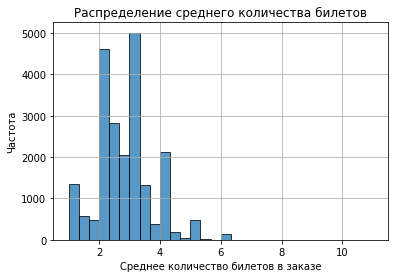

In [91]:
user_profile['avg_tickets_count'].plot(
                kind='hist',
                bins=30,
                alpha=0.75,
                edgecolor='black',
                rot=0
)

plt.title('Распределение среднего количества билетов')
plt.xlabel('Среднее количество билетов в заказе')
plt.ylabel('Частота')
plt.grid()

# Выводим график
plt.show()

По графику видно, что чаще всего в заказе вчтречаются 2-3 билета, а реже всего - 7 и больше.

In [92]:
# добавим строку для избегания ошибки в следующем коде о том, что таблица user_profile является срезом датасета
user_profile = user_profile.copy()

In [93]:
# создадим функцию для фильтрации пользователей по среднему количеству билетов в заказе
def avg_tickets_count_categ(value):
    if value <2:
        return '1-2 билета'
    elif value <3:
        return '2-3 билета'
    elif value <5:
        return '3-5 билетов'
    else:
        return '5 и более билетов'
    
# создадим новый столбец с категориями
user_profile['avg_tickets_count_category'] = user_profile['avg_tickets_count'].apply(avg_tickets_count_categ)    
user_profile

,user_id,first_order_dt,last_order_dt,orders_count,avg_revenue_rub,avg_tickets_count,avg_days_since_prev,device_type_canonical,region_name,service_name,event_type_main,is_two,is_five,avg_tickets_count_category
0,0002849b70a3ce2,2024-08-20,2024-08-20,1,1521.939941,4.000000,0.000000,mobile,Каменевский регион,край билетов,театр,0,0,3-5 билетов
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,2,774.010010,3.000000,37.500000,mobile,Каменевский регион,мой билет,выставки,1,0,3-5 билетов
2,000898990054619,2024-07-13,2024-10-23,3,767.213318,2.666667,34.000000,mobile,Североярская область,лови билет!,другое,1,0,2-3 билета
3,00096d1f542ab2b,2024-08-15,2024-08-15,1,917.830017,4.000000,0.000000,desktop,Каменевский регион,край билетов,театр,0,0,3-5 билетов
4,000a55a418c128c,2024-09-29,2024-10-15,2,61.309998,1.500000,8.000000,mobile,Поленовский край,лучшие билеты,театр,1,0,1-2 билета
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21833,fff13b79bd47d7c,2024-07-16,2024-10-31,9,688.043335,2.555556,11.888889,mobile,Каменевский регион,мой билет,другое,1,1,2-3 билета
21834,fff32fc9ad0f9f6,2024-08-15,2024-10-28,2,850.994995,2.500000,37.000000,desktop,Каменевский регион,билеты без проблем,стендап,1,0,2-3 билета
21835,fffcd3dde79eb2c,2024-06-20,2024-10-30,33,557.908508,2.787879,4.000000,desktop,Каменевский регион,билеты без проблем,концерты,1,1,2-3 билета
21836,fffeeb3c120cf0b,2024-09-24,2024-09-24,1,661.530029,2.000000,0.000000,desktop,Широковская область,билеты без проблем,стендап,0,0,2-3 билета


In [94]:
# подсчитаем для каждого сегмента общее число пользователей и долю пользователей, совершивших повторные заказы
user_profile.groupby('avg_tickets_count_category').agg({'user_id':'count','is_two':'mean'}).sort_values(
    by='user_id',ascending = False)

,user_id,is_two
avg_tickets_count_category,,
2-3 билета,9487,0.735638
3-5 билетов,9065,0.542967
1-2 билета,2410,0.512448
5 и более билетов,660,0.186364


Подавляющее большинство пользователей сосредоточено в двух сегментах - "2-3 билета" (9487 пользователей) и "3-5 билетов" (9065 пользователей). Пользователей с самым большим количеством билетов в заказе меньше всего (660 пользователей), при этом доля повторных покупок тоже является для них низкой - 19%.
У пользователей с 2-3 покупками самая высокая доля повторных покупок - 74%.

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучим временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируем, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделим день недели.
- Для каждого дня недели подсчитаем общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответим на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [95]:
# создадим столбец с днем недели первого заказа
user_profile['first_order_weekday'] = user_profile['first_order_dt'].dt.day_name()
user_profile

,user_id,first_order_dt,last_order_dt,orders_count,avg_revenue_rub,avg_tickets_count,avg_days_since_prev,device_type_canonical,region_name,service_name,event_type_main,is_two,is_five,avg_tickets_count_category,first_order_weekday
0,0002849b70a3ce2,2024-08-20,2024-08-20,1,1521.939941,4.000000,0.000000,mobile,Каменевский регион,край билетов,театр,0,0,3-5 билетов,Tuesday
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,2,774.010010,3.000000,37.500000,mobile,Каменевский регион,мой билет,выставки,1,0,3-5 билетов,Tuesday
2,000898990054619,2024-07-13,2024-10-23,3,767.213318,2.666667,34.000000,mobile,Североярская область,лови билет!,другое,1,0,2-3 билета,Saturday
3,00096d1f542ab2b,2024-08-15,2024-08-15,1,917.830017,4.000000,0.000000,desktop,Каменевский регион,край билетов,театр,0,0,3-5 билетов,Thursday
4,000a55a418c128c,2024-09-29,2024-10-15,2,61.309998,1.500000,8.000000,mobile,Поленовский край,лучшие билеты,театр,1,0,1-2 билета,Sunday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21833,fff13b79bd47d7c,2024-07-16,2024-10-31,9,688.043335,2.555556,11.888889,mobile,Каменевский регион,мой билет,другое,1,1,2-3 билета,Tuesday
21834,fff32fc9ad0f9f6,2024-08-15,2024-10-28,2,850.994995,2.500000,37.000000,desktop,Каменевский регион,билеты без проблем,стендап,1,0,2-3 билета,Thursday
21835,fffcd3dde79eb2c,2024-06-20,2024-10-30,33,557.908508,2.787879,4.000000,desktop,Каменевский регион,билеты без проблем,концерты,1,1,2-3 билета,Thursday
21836,fffeeb3c120cf0b,2024-09-24,2024-09-24,1,661.530029,2.000000,0.000000,desktop,Широковская область,билеты без проблем,стендап,0,0,2-3 билета,Tuesday


In [96]:
# сгруппируем профиль пользователя по дням недели
weekday_grouped = user_profile.groupby('first_order_weekday').agg({'user_id':'count','is_two':'mean'}).sort_values(
    by='user_id', ascending = False).reset_index()
weekday_grouped 

,first_order_weekday,user_id,is_two
0,Saturday,3323,0.627746
1,Friday,3256,0.597666
2,Tuesday,3175,0.618898
3,Thursday,3112,0.594473
4,Wednesday,3061,0.622672
5,Monday,2918,0.629883
6,Sunday,2777,0.600648


<Figure size 720x432 with 0 Axes>

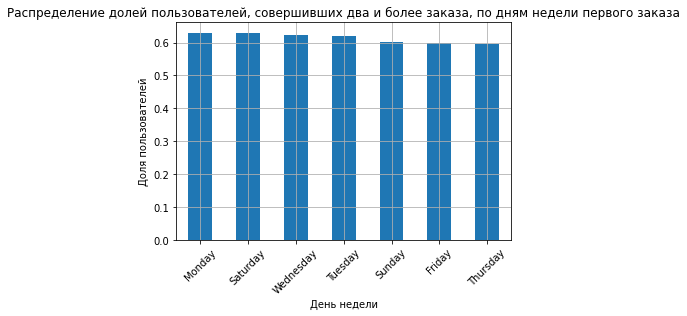

In [97]:
# Построим столбчатую диаграмму и нанесем на график линию с средним значением доли пользователей
plt.figure(figsize=(10, 6))

weekday_grouped.sort_values(by='is_two', ascending = False).plot(
               kind='bar',
               rot=45,
               legend=False,
               x='first_order_weekday',
               y='is_two',
               title=f'Распределение долей пользователей, совершивших два и более заказа, по дням недели первого заказа'
)

plt.xlabel('День недели')
plt.ylabel('Доля пользователей')
plt.grid()

plt.show()

По результатам группировки видно, что больше всего заказов совершается в субботу и пятницу, а по диаграмме можно сделать вывод, что день недели почти не оказывает влияния на долю возвратов клиентов.

---

**Задача 4.3.2.** Изучим, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитаем среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуем, как средний интервал между заказами влияет на вероятность повторного заказа.

---


In [98]:
# создадим таблицу, где оставим только 2-4 заказа
orders_2_4 = user_profile.loc[(user_profile['is_two']==1) & (user_profile['is_five']==0)]
orders_2_4 

,user_id,first_order_dt,last_order_dt,orders_count,avg_revenue_rub,avg_tickets_count,avg_days_since_prev,device_type_canonical,region_name,service_name,event_type_main,is_two,is_five,avg_tickets_count_category,first_order_weekday
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,2,774.010010,3.000000,37.5,mobile,Каменевский регион,мой билет,выставки,1,0,3-5 билетов,Tuesday
2,000898990054619,2024-07-13,2024-10-23,3,767.213318,2.666667,34.0,mobile,Североярская область,лови билет!,другое,1,0,2-3 билета,Saturday
4,000a55a418c128c,2024-09-29,2024-10-15,2,61.309998,1.500000,8.0,mobile,Поленовский край,лучшие билеты,театр,1,0,1-2 билета,Sunday
6,00147c9209d45d3,2024-06-25,2024-06-25,2,352.945007,1.500000,0.0,mobile,Каменевский регион,облачко,концерты,1,0,1-2 билета,Tuesday
9,001e7037d013f0f,2024-07-04,2024-09-29,3,326.623322,1.333333,29.0,mobile,Златопольский округ,мой билет,другое,1,0,1-2 билета,Thursday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21829,ffe3c623370fc5c,2024-08-11,2024-08-11,2,1065.175049,2.500000,0.0,mobile,Медовская область,лови билет!,театр,1,0,2-3 билета,Sunday
21830,ffe73c50cbd71fc,2024-09-15,2024-09-15,2,548.739990,2.000000,0.0,mobile,Заречная область,тебе билет!,концерты,1,0,2-3 билета,Sunday
21831,ffecf05f1f6a9c6,2024-06-03,2024-08-02,4,818.710022,2.250000,15.0,mobile,Североярская область,билеты без проблем,концерты,1,0,2-3 билета,Monday
21832,ffed3ff067d4f12,2024-07-31,2024-10-17,4,50.514999,2.250000,19.5,mobile,Малиновая область,лучшие билеты,другое,1,0,2-3 билета,Wednesday


In [99]:
# создадим таблицу, где оставим только 5 заказов и более
orders_5_more = user_profile.loc[user_profile['is_five']==1]
orders_5_more 

,user_id,first_order_dt,last_order_dt,orders_count,avg_revenue_rub,avg_tickets_count,avg_days_since_prev,device_type_canonical,region_name,service_name,event_type_main,is_two,is_five,avg_tickets_count_category,first_order_weekday
5,000cf0659a9f40f,2024-06-20,2024-06-21,13,1175.808472,3.307692,0.076923,mobile,Широковская область,лови билет!,концерты,1,1,3-5 билетов,Thursday
13,002b75ca606ba46,2024-07-08,2024-10-16,6,443.580017,3.000000,16.666667,desktop,Каменевский регион,быстробилет,концерты,1,1,3-5 билетов,Monday
15,002ec276eee9b0b,2024-07-10,2024-10-31,22,811.942749,2.863636,5.136364,mobile,Широковская область,мой билет,концерты,1,1,2-3 билета,Wednesday
16,0033403583a55ed,2024-06-19,2024-09-17,6,135.692291,1.666667,15.000000,mobile,Каменевский регион,билеты без проблем,другое,1,1,1-2 билета,Wednesday
18,00345f897f95a34,2024-06-02,2024-10-23,8,1338.258789,2.875000,17.875000,mobile,Лесодальний край,тебе билет!,концерты,1,1,2-3 билета,Sunday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21819,ffcc69d883faddc,2024-08-24,2024-10-26,24,360.922485,2.583333,2.625000,mobile,Серебринская область,лови билет!,спорт,1,1,2-3 билета,Saturday
21822,ffd530dc2b699b0,2024-06-06,2024-09-16,7,492.728577,2.714286,14.571429,mobile,Травяная область,лови билет!,другое,1,1,2-3 билета,Thursday
21825,ffdadadd5de9c4b,2024-06-09,2024-10-25,15,429.164001,2.133333,9.200000,mobile,Североярская область,билеты без проблем,концерты,1,1,2-3 билета,Sunday
21833,fff13b79bd47d7c,2024-07-16,2024-10-31,9,688.043335,2.555556,11.888889,mobile,Каменевский регион,мой билет,другое,1,1,2-3 билета,Tuesday


In [100]:
# рассчитаем средний интервал между заказами
print(orders_2_4['avg_days_since_prev'].mean())
print(orders_5_more['avg_days_since_prev'].mean())

12.51821130244062
8.59977535196035


По результатам вычислений делаем вывод, что пользователи с 5 и более заказами возвращаются чаще, так как средний интервал между заказами у них ниже. Значит, более активные клиенты возвращаются за покупками чаще.

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [101]:
# загружаем библиотеку для расчёта коэффициента корреляции phi_k
!pip install phik
from phik import phik_matrix

In [102]:
#Рассчитаем матрицу корреляции
correlation_matrix = user_profile[['orders_count', 'avg_revenue_rub', 'avg_tickets_count', 'avg_days_since_prev',
                         'device_type_canonical','region_name','service_name','event_type_main']
      ].phik_matrix(interval_cols = ['orders_count', 'avg_revenue_rub','avg_tickets_count','avg_days_since_prev'])
correlation_matrix

,orders_count,avg_revenue_rub,avg_tickets_count,avg_days_since_prev,device_type_canonical,region_name,service_name,event_type_main
orders_count,1.000000,0.219483,0.225350,0.098442,0.030162,0.117504,0.029794,0.024930
avg_revenue_rub,0.219483,1.000000,0.456871,0.105978,0.073683,0.358697,0.379249,0.327159
avg_tickets_count,0.225350,0.456871,1.000000,0.092175,0.053781,0.160570,0.060550,0.094484
avg_days_since_prev,0.098442,0.105978,0.092175,1.000000,0.003664,0.060065,0.034811,0.038201
device_type_canonical,0.030162,0.073683,0.053781,0.003664,1.000000,0.115241,0.086031,0.063000
region_name,0.117504,0.358697,0.160570,0.060065,0.115241,1.000000,0.696825,0.509107
service_name,0.029794,0.379249,0.060550,0.034811,0.086031,0.696825,1.000000,0.588770
event_type_main,0.024930,0.327159,0.094484,0.038201,0.063000,0.509107,0.588770,1.000000


In [103]:
# отсортируем столбец 'orders_count' по значению коэффициента
correlation_matrix['orders_count'].sort_values(ascending = False)

orders_count             1.000000
avg_tickets_count        0.225350
avg_revenue_rub          0.219483
region_name              0.117504
avg_days_since_prev      0.098442
device_type_canonical    0.030162
service_name             0.029794
event_type_main          0.024930
Name: orders_count, dtype: float64

По результатам расчета корреляции phi_k была проанализирована связь между признаками профиля пользователя и количеством заказов.
Наиболее сильная связь наблюдается между числом заказов и признаками `avg_tickets_count` (0,26) и `avg_revenue_rub` (0,22). Это может говорить о том, что пользователи, совершающие более дорогие или большие по количеству билетов в заказе покупки, делают больше заказов.
Остальные признаки демонстрируют слабую связь с числом заказов.
При этом можно сделать вывод, что сильной зависимости между числом заказов и остальными признаками профиля пользователя не наблюдается.

In [104]:
# выведем статистические показатели по столбцу с количеством заказов
user_profile['orders_count'].describe()

count    21622.000000
mean         6.496439
std         14.310273
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max        152.000000
Name: orders_count, dtype: float64

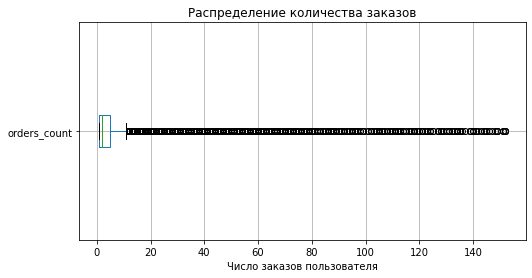

In [105]:
# построим диаграмму размаха
plt.figure(figsize=(8, 4))

user_profile.boxplot(column='orders_count', vert=False)

plt.title('Распределение количества заказов')
plt.xlabel('Число заказов пользователя')

plt.show()

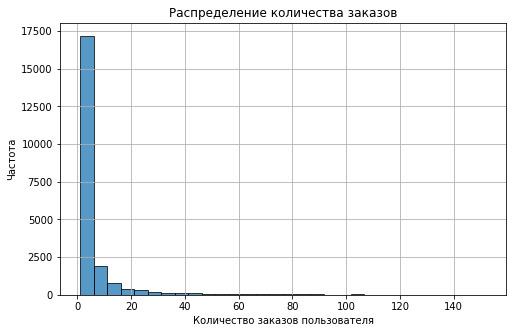

In [106]:
# создадим гистограмму
plt.figure(figsize=(8, 5))

user_profile['orders_count'].plot(
                kind='hist',
                bins=30,
                alpha=0.75,
                edgecolor='black',
                rot=0
)

plt.title('Распределение количества заказов')
plt.xlabel('Количество заказов пользователя')
plt.ylabel('Частота')
plt.grid()

plt.show()

На основе статистических данных столбца `orders_count`, построения диаграммы размаха и гистограммы, можно увидеть, что разброс данных в столбце очень большой, максимальное значение составляет 152 заказа у пользователя, тогда как среднее - 6,5, а медиана - 2.
При этом у большинства пользователей количество заказов стремится к единице, а судя по диаграмме разброса, в данных содержится много выбросов.

In [107]:
user_profile.head()

,user_id,first_order_dt,last_order_dt,orders_count,avg_revenue_rub,avg_tickets_count,avg_days_since_prev,device_type_canonical,region_name,service_name,event_type_main,is_two,is_five,avg_tickets_count_category,first_order_weekday
0,0002849b70a3ce2,2024-08-20,2024-08-20,1,1521.939941,4.000000,0.0,mobile,Каменевский регион,край билетов,театр,0,0,3-5 билетов,Tuesday
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,2,774.010010,3.000000,37.5,mobile,Каменевский регион,мой билет,выставки,1,0,3-5 билетов,Tuesday
2,000898990054619,2024-07-13,2024-10-23,3,767.213318,2.666667,34.0,mobile,Североярская область,лови билет!,другое,1,0,2-3 билета,Saturday
3,00096d1f542ab2b,2024-08-15,2024-08-15,1,917.830017,4.000000,0.0,desktop,Каменевский регион,край билетов,театр,0,0,3-5 билетов,Thursday
4,000a55a418c128c,2024-09-29,2024-10-15,2,61.309998,1.500000,8.0,mobile,Поленовский край,лучшие билеты,театр,1,0,1-2 билета,Sunday


In [108]:
# создадим функцию для фильтрации пользователей по количеству заказов
def orders_count_categ(value):
    if value <2:
        return '1 заказ'
    elif value <5:
        return '2-4 заказа'
    else:
        return '5 и более билетов'
    
# создадим новый столбец с категориями
user_profile['orders_count_category'] = user_profile['orders_count'].apply(orders_count_categ)    
user_profile

,user_id,first_order_dt,last_order_dt,orders_count,avg_revenue_rub,avg_tickets_count,avg_days_since_prev,device_type_canonical,region_name,service_name,event_type_main,is_two,is_five,avg_tickets_count_category,first_order_weekday,orders_count_category
0,0002849b70a3ce2,2024-08-20,2024-08-20,1,1521.939941,4.000000,0.000000,mobile,Каменевский регион,край билетов,театр,0,0,3-5 билетов,Tuesday,1 заказ
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,2,774.010010,3.000000,37.500000,mobile,Каменевский регион,мой билет,выставки,1,0,3-5 билетов,Tuesday,2-4 заказа
2,000898990054619,2024-07-13,2024-10-23,3,767.213318,2.666667,34.000000,mobile,Североярская область,лови билет!,другое,1,0,2-3 билета,Saturday,2-4 заказа
3,00096d1f542ab2b,2024-08-15,2024-08-15,1,917.830017,4.000000,0.000000,desktop,Каменевский регион,край билетов,театр,0,0,3-5 билетов,Thursday,1 заказ
4,000a55a418c128c,2024-09-29,2024-10-15,2,61.309998,1.500000,8.000000,mobile,Поленовский край,лучшие билеты,театр,1,0,1-2 билета,Sunday,2-4 заказа
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21833,fff13b79bd47d7c,2024-07-16,2024-10-31,9,688.043335,2.555556,11.888889,mobile,Каменевский регион,мой билет,другое,1,1,2-3 билета,Tuesday,5 и более билетов
21834,fff32fc9ad0f9f6,2024-08-15,2024-10-28,2,850.994995,2.500000,37.000000,desktop,Каменевский регион,билеты без проблем,стендап,1,0,2-3 билета,Thursday,2-4 заказа
21835,fffcd3dde79eb2c,2024-06-20,2024-10-30,33,557.908508,2.787879,4.000000,desktop,Каменевский регион,билеты без проблем,концерты,1,1,2-3 билета,Thursday,5 и более билетов
21836,fffeeb3c120cf0b,2024-09-24,2024-09-24,1,661.530029,2.000000,0.000000,desktop,Широковская область,билеты без проблем,стендап,0,0,2-3 билета,Tuesday,1 заказ


In [109]:
# проверим распределение по сегментам 
user_profile['orders_count_category'].value_counts(normalize=True)

1 заказ              0.386782
2-4 заказа           0.330358
5 и более билетов    0.282860
Name: orders_count_category, dtype: float64

Мы видим, что больше всего (39%) пользователей с единичными заказами, а меньше всего - с крупными (от 5 и более).

In [110]:
# рассчитаем матрицу корреляции снова
correlation_matrix_new = user_profile[['orders_count', 'avg_revenue_rub', 'avg_tickets_count', 'avg_days_since_prev',
                'device_type_canonical','region_name','service_name','event_type_main','orders_count_category']
      ].phik_matrix(interval_cols = ['orders_count', 'avg_revenue_rub','avg_tickets_count','avg_days_since_prev'])
correlation_matrix_new

,orders_count,avg_revenue_rub,avg_tickets_count,avg_days_since_prev,device_type_canonical,region_name,service_name,event_type_main,orders_count_category
orders_count,1.000000,0.219483,0.225350,0.098442,0.030162,0.117504,0.029794,0.024930,0.488036
avg_revenue_rub,0.219483,1.000000,0.456871,0.105978,0.073683,0.358697,0.379249,0.327159,0.325294
avg_tickets_count,0.225350,0.456871,1.000000,0.092175,0.053781,0.160570,0.060550,0.094484,0.383043
avg_days_since_prev,0.098442,0.105978,0.092175,1.000000,0.003664,0.060065,0.034811,0.038201,0.601894
device_type_canonical,0.030162,0.073683,0.053781,0.003664,1.000000,0.115241,0.086031,0.063000,0.019263
region_name,0.117504,0.358697,0.160570,0.060065,0.115241,1.000000,0.696825,0.509107,0.123499
service_name,0.029794,0.379249,0.060550,0.034811,0.086031,0.696825,1.000000,0.588770,0.079372
event_type_main,0.024930,0.327159,0.094484,0.038201,0.063000,0.509107,0.588770,1.000000,0.038181
orders_count_category,0.488036,0.325294,0.383043,0.601894,0.019263,0.123499,0.079372,0.038181,1.000000


In [111]:
#выведем результат корреляции столбца orders_count_category с остальными
correlation_matrix_new.loc[correlation_matrix_new.index != 'orders_count_category'][['orders_count_category']
                                                        ].sort_values(by='orders_count_category', ascending=False)

,orders_count_category
avg_days_since_prev,0.601894
orders_count,0.488036
avg_tickets_count,0.383043
avg_revenue_rub,0.325294
region_name,0.123499
service_name,0.079372
event_type_main,0.038181
device_type_canonical,0.019263


Text(0.5, 32.09375, 'Количество заказов')

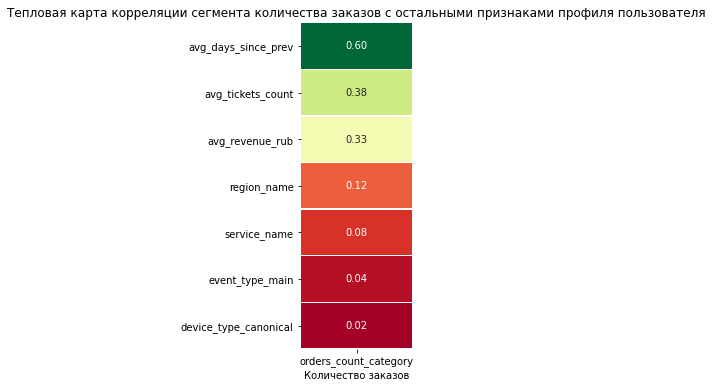

In [112]:
# загрузим библиотеку для тепловой карты
import seaborn as sns

# построим тепловую карту
plt.figure(figsize=(2, 6))
data_heatmap = correlation_matrix_new.loc[
    (correlation_matrix_new.index != 'orders_count_category') & (correlation_matrix_new.index != 'orders_count')][['orders_count_category']
                                                        ].sort_values(by='orders_count_category', ascending=False)
sns.heatmap(data_heatmap,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            linewidths=0.5,
            cbar=False
           )

plt.title('Тепловая карта корреляции сегмента количества заказов с остальными признаками профиля пользователя')
plt.xlabel('Количество заказов')

Таким образом, самая сильная корреляция у столбца `orders_count_category` со столбцами `avg_days_since_prev`,  `avg_tickets_count` и `avg_revenue_rub`.
Это может значить, что чем меньше дней между заказами, тем больше заказов у пользователя, а количество заказов и лояльность покупателя зависит от количества билетов в заказе и выручки. 
Это подтверждает ранее сделанный вывод о том, что многократные пользователи часто совершают заказы с выручкой около 500 рублей.

## 5. Общий вывод и рекомендации

**Информация о данных**

Исходный датасет содержал 290 611 записей о покупках в Яндекс Афише (15 столбцов: данные о пользователях, заказах, мероприятиях, регионах и т.д.).
В ходе предобработки выполнены:
- Конвертация выручки из казахстанских тенге в рубли по курсу на дату покупки (создан новый столбец revenue_rub).
- Замена пропусков в days_since_prev на 0.
- Удаление строк - отрицательная выручка, выбросы по выручке выше 99-го перцентиля, выбросы по количеству билетов свыше 16 шт.

**Основные результаты анализа**

Для анализа акже был создан профиль пользователя, в который попали 21 622 уникальных пользователя.
Наиболее важные статистические показатели по пользователям и заказам:
- Средняя выручка в рублях на один заказ - 518,71 руб,
- Доля пользователей, совершивших 2 и более заказа — 61,7%,
- Доля пользователей, совершивших 5 и более заказов — 29%,
- Медиана числа заказов пользователя — 2, среднее — 6,5,
- 39% совершают только одну покупку.

Признаки первого заказа, связанные с возвратом пользователей:
- Тип мероприятия - покупатели выставок вовращаются чаще всего (в 64% случаев), однако этот сегмент представлен небольшим количеством пользователей, поэтому результат может быть нерепрезентативен. Гипотеза о спорте не подтвердилась – пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ реже, чем пользователи, оформившие свой первый заказ на концерты
- Тип устройства - мобильные пользователи возвращаются чуть чаще (64% против 63% у стационарного компьютера), разница незначительна.
- Регион и день недели первого заказа практически не влияют на вероятность повторной покупки.

Связь средней выручки и количества билетов с повторными покупками:
- Корреляционный анализ подтвердил наличие сильной зависимости между количеством заказов пользователя и средней выручкой, а также количеством билетов.
- У пользователей с единичными заказами пик средней выручки приходится на значение около нуля, у пользователей с многократным числом покупок – около 500 руб.
- Самая высокая доля повторных покупок (74%) у пользователей, покупающих в среднем 2–3 билета на заказ.
- Пользователи с 5 и более билетами в заказе возвращаются реже всего (в 19% случаев), возможно, это групповые разовые покупки.

Временные характеристики:
- У активных клиентов (5 и более заказов) средний интервал между заказами – 8,6 дня, у менее активных (2–4 заказа) – 12,5 дней, то есть чем чаще покупки, тем выше вероятность повторного заказа.
- Больше всего заказов совершается в субботу и пятницу, при этом день недели почти не оказывает влияния на долю возвратов клиентов.

Корреляционный анализ:
- Наиболее сильная связь с количеством заказов, разделенным на сегменты "1 заказ", "2-4 заказа", "5 и более заказов", обнаружена у столбца `avg_days_since_prev` (коэффициент корреляции phi_k = 0,60).
- Среднее количество билетов (коэффициент = 0,38) и средняя выручка (коэффициент = 0,33) также оказывают существенное влияние.
- Регион, билетный оператор, тип мероприятия и устройство имеют очень слабую связь (≤ 0,12), значит, количество заказов не зависит от этих признаков.

**Рекомендации команде маркетинга**

1. Сосредоточиться на самых лояльных клиентах - покупателях с 2-3 билетами в заказе со средним чеком в ~500 руб., например, вводить для таких клиентов специальные предложения, настроить систему рекомендаций.
2. Так как доля пользователей с единичными заказами довольно высокая, вводить механизмы для совершения ими повторной покупки в течение короткого периода времени для сокращения в том числе интервала между заказами, например, предлагать промокоды, действующие в течение короткого периода времени, или скидку на повторный заказ.
3. Проверить пользователей с большим количеством заказом (например, пользователя с 10168 заказов) на предмет сбоев в системе, принадлежности к тестовым аккаунтам, исключить при необходимости и повторить исследование.

## 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**